# Setup

## Install & Import Libs

In [4]:
# Install Packages
!pip install catboost

# Import Libraries
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Setting Global
warnings.filterwarnings('ignore')
sklearn.set_config(transform_output="pandas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/noctican/10-MuhammadArsyadSetiawan-CandraAndikaPutra/refs/heads/main/ai_worker_burnout_attrition_2026.csv')

In [6]:
df.drop(columns=['employee_id', 'attrition_risk'], inplace=True)

## Feature Engineering 1

### Binning Target

In [7]:
interval = (df['job_satisfaction_1_5'].max() - df['job_satisfaction_1_5'].min())/3
low_max_inter = df['job_satisfaction_1_5'].min() +  interval
med_max_inter = low_max_inter + interval
high_max_inter = med_max_inter + interval

low = [0, low_max_inter]
medium = [low_max_inter, med_max_inter]
high = [med_max_inter, high_max_inter]

print('low: ',low)
print('medium: ',medium)
print('high: ',high)

low:  [0, 2.533333333333333]
medium:  [2.533333333333333, 3.7666666666666666]
high:  [3.7666666666666666, 5.0]


In [8]:
bins = [0, low_max_inter, med_max_inter, high_max_inter]
kelas_text = ['Low', 'Medium/Neutral', 'High']
kelas = [0, 1, 2]
df['job_satisfaction_category'] = pd.cut(df['job_satisfaction_1_5'], bins=bins, labels=kelas)

### Math Tunning

In [ ]:
math_cols = ['work_life_balance', 'ai_dependency', 'ai_threat_score',
            'upskilling_effort', 'productivity_per_ai_hour', 'salary_per_experience']

class AddMathFeature(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_new = X.copy()

        # 1. Work-Life Balance Score
        if 'burnout_score' in X_new.columns and 'productivity_score' in X_new.columns:
            X_new['work_life_balance'] = X_new['productivity_score'] - X_new['burnout_score']

        # 2. AI Dependency Score
        if 'hours_with_ai_assistance_daily' in X_new.columns and 'ai_tools_used_per_day' in X_new.columns:
            X_new['ai_dependency'] = X_new['hours_with_ai_assistance_daily'] * X_new['ai_tools_used_per_day']

        # 3. AI Threat Score
        if 'ai_replaces_my_tasks_pct' in X_new.columns and 'fear_of_ai_replacement' in X_new.columns:
            fear_map = {'Low': 1, 'Medium': 2, 'High': 3}
            X_new['fear_numeric'] = X_new['fear_of_ai_replacement'].map(fear_map)
            X_new['ai_threat_score'] = X_new['ai_replaces_my_tasks_pct'] * X_new['fear_numeric']
            X_new.drop('fear_numeric', axis=1, inplace=True)

        # 4. Upskilling Effort
        if 'weekly_ai_upskilling_hrs' in X_new.columns and 'years_experience' in X_new.columns:
            X_new['upskilling_effort'] = X_new['weekly_ai_upskilling_hrs'] / (X_new['years_experience'] + 1)

        # 5. Productivity per hour with AI
        if 'productivity_score' in X_new.columns and 'hours_with_ai_assistance_daily' in X_new.columns:
            X_new['productivity_per_ai_hour'] = X_new['productivity_score'] / (X_new['hours_with_ai_assistance_daily'] + 1)

        # 6. Experience to salary ratio
        if 'years_experience' in X_new.columns and 'salary_usd_k' in X_new.columns:
            X_new['salary_per_experience'] = X_new['salary_usd_k'] / (X_new['years_experience'] + 1)

        return X_new


math_tunning = AddMathFeature()
df_w_math = df.copy()
df_w_math = math_tunning.fit_transform(df_w_math)

## Preprocessing

### Normalisasi

In [10]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

std_cols = ['productivity_score', 'burnout_score'] + math_cols
minmax_cols = ['years_experience', 'team_size', 'salary_usd_k', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs']

### Encoding

In [11]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['job_role', 'education_level', 'country', 'industry', 'company_size',
       'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage',
       'fear_of_ai_replacement'],
      dtype='object')

In [12]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

job_role: ['Data Analyst' 'DevOps Engineer' 'Prompt Engineer' 'Backend Engineer'
 'AI Researcher' 'AI Ethics Officer' 'Data Scientist' 'Product Manager'
 'ML Engineer' 'Cloud Architect' 'Software Engineer' 'Frontend Engineer']
education_level: ['PhD' 'Self-taught' 'Master' 'Bachelor' 'Bootcamp']
country: ['India' 'Canada' 'Germany' 'USA' 'Singapore' 'Netherlands' 'UK'
 'Australia' 'Brazil' 'France']
industry: ['Healthtech' 'Fintech' 'Automotive' 'Media' 'E-commerce' 'Gaming'
 'Consulting' 'Cybersecurity' 'EdTech' 'SaaS']
company_size: ['Large (1000-5000)' 'Startup (<50)' 'Mid (200-1000)' 'Small (50-200)'
 'Enterprise (5000+)']
remote_work_type: ['Fully Remote' 'Hybrid' 'On-site']
primary_ai_tool: ['GitHub Copilot' 'ChatGPT' 'Midjourney' 'Perplexity' 'Notion AI' 'Cursor'
 'Claude' 'Gemini']
ai_adoption_stage: ['Experimenting' 'Optimizing' 'Integrating' 'AI-First']
fear_of_ai_replacement: ['Low' 'Medium' 'High']


### Ordinal

In [13]:
target_mapping = {'Low': 0, 'Medium/Neutral': 1, 'High': 2}

education_mapping = ['Self-taught', 'Bootcamp', 'Bachelor', 'Master', 'PhD']

company_size_mapping = ['Startup (<50)', 'Small (50-200)', 'Mid (200-1000)', 'Large (1000-5000)', 'Enterprise (5000+)']

ai_adoption_mapping = ['Experimenting', 'Optimizing', 'Integrating', 'AI-First']

fear_mapping = ['Low', 'Medium', 'High']

ordinal_cols = [
    'education_level',
    'company_size',
    'ai_adoption_stage',
    'fear_of_ai_replacement',
]

ordinal_cols_mapping = [
    education_mapping,
    company_size_mapping,
    ai_adoption_mapping,
    fear_mapping,
]

In [14]:
df['job_satisfaction_category'] = df['job_satisfaction_category'].map(target_mapping)
ord_enc = OrdinalEncoder(categories=ordinal_cols_mapping)

### Nominal

In [15]:
ohe_cols = [
    'job_role',
    'country',
    'industry',
    'remote_work_type',
    'primary_ai_tool'
]

In [16]:
ohe_enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

### Balancing Data

In [17]:
smote = SMOTE(random_state=42)
smote_tomek = SMOTETomek(random_state=42)

### Feature Selection

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

selected_feat = [
    'burnout_score', 'country', 'remote_work_type', 'weekly_ai_upskilling_hrs',
    'productivity_score', 'hours_with_ai_assistance_daily', 'salary_usd_k',
    'fear_of_ai_replacement', 'team_size', 'ai_replaces_my_tasks_pct',
    'primary_ai_tool', 'years_experience', 'education_level', 'ai_tools_used_per_day'
]

class ManualFS(BaseEstimator, TransformerMixin):
    def __init__(self, selected_features):
        self.selected_features = selected_features
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = X.columns
        return self

    def transform(self, X):
        if not hasattr(X, 'columns'):
            if self.feature_names_in_ is not None:
                X = pd.DataFrame(X, columns=self.feature_names_in_)
            else:
                raise ValueError("X kehilangan nama kolom.")

        cols_to_select = [col for col in self.selected_features if col in X.columns]
        return X[cols_to_select].copy()

In [19]:
manual_xgb_selector = ManualFS(selected_features = selected_feat + math_cols)
rf_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    threshold="median"
)

## Data Splitting

In [20]:
X = df_w_math.drop(['job_satisfaction_category', 'job_satisfaction_1_5'], axis=1)
y = df_w_math['job_satisfaction_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Global Helper

### Pipeline

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

def get_prepo(wScale, fs):
    # Tentukan fitur yang masuk berdasarkan algoritma
    if fs == 'manual':
        fitur_masuk = selected_feat + math_cols
    else:
        fitur_masuk = std_cols + minmax_cols + ordinal_cols + ohe_cols

    # Saring kolom berdasarkan fitur yang masuk
    final_std_cols = [col for col in std_cols if col in fitur_masuk]
    final_minmax_cols = [col for col in minmax_cols if col in fitur_masuk]
    final_ohe_cols = [col for col in ohe_cols if col in fitur_masuk]

    # Saring Ordinal dan Mapping-nya dengan aman
    final_ordinal_cols = []
    final_ordinal_mapping = []
    for col, mapping in zip(ordinal_cols, ordinal_cols_mapping):
        if col in fitur_masuk:
            final_ordinal_cols.append(col)
            final_ordinal_mapping.append(mapping)

    ord_enc_filtered = OrdinalEncoder(
        categories=final_ordinal_mapping,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    ohe_enc_filtered = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

    if wScale:
        return ColumnTransformer([
            ('std_scaler', StandardScaler(), final_std_cols),
            ('minmax_scaler', MinMaxScaler(), final_minmax_cols),
            ('ordinal', ord_enc_filtered, final_ordinal_cols),
            ('ohe', ohe_enc_filtered, final_ohe_cols)
        ], remainder='drop')
    else:
        return ColumnTransformer([
            ('ordinal', ord_enc_filtered, final_ordinal_cols),
            ('ohe', ohe_enc_filtered, final_ohe_cols)
        ], remainder='passthrough')

In [22]:
# prepo_w_scaler = ColumnTransformer([
#   ('std_scaler', std_scaler, final_std_cols),
#   ('minmax_scaler', minmax_scaler, final_minmax_cols),
#   ('ordinal', ord_enc, final_ordinal_cols),
#   ('ohe', ohe_enc, final_ohe_cols)
# ], remainder='drop')

# prepo_wo_scaler = ColumnTransformer([
#   ('ordinal', ord_enc, final_ordinal_cols),
#   ('ohe', ohe_enc, final_ohe_cols)
# ], remainder='passthrough')

def getPipeline(model, wScale=True, wSmote=True, fs='manual'):
    prepo = get_prepo(wScale, fs)

    # Atur SMOTE
    if wSmote and fs == 'manual':
        step_smote = smote
    elif wSmote:
        step_smote = smote_tomek
    else:
        step_smote = None

    # Rakit urutan pipeline
    steps = [('math_tunning', math_tunning)]

    if fs == 'manual':
        steps.append(('manual_selection', manual_xgb_selector))

    steps.append(('prepo', prepo))

    if step_smote is not None:
        steps.append(('smote', step_smote))

    if fs != 'manual':
        steps.append(('model_feature_selection', rf_selector))

    steps.append(('model', model))

    return ImbPipeline(steps)

### Metric

In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.model_selection import cross_val_score

def evaluate_final_metrics(pipeline, model_name="Model", cv_folds=5):
    print(f"⏳ Sedang memproses evaluasi untuk {model_name}...")

    # 1. Hitung CV Accuracy Mean menggunakan data train
    cv_acc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv_folds, scoring='accuracy')
    cv_acc_mean = cv_acc_scores.mean()

    # 2. Fit pipeline ke seluruh data latih (Train)
    pipeline.fit(X_train, y_train)

    # 3. Prediksi data Train dan data Test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # 4. Hitung semua metrik
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1_macro = f1_score(y_test, y_pred_test, average='macro')
    test_prec_macro = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_rec_macro = recall_score(y_test, y_pred_test, average='macro')

    # --- CETAK HASIL ---
    print("\n" + "="*55)
    print(f"🏆 SUMMARY METRICS : {model_name.upper()} 🏆")
    print("="*55)
    print(f"1. Train Accuracy           : {train_acc:.4f}")
    print(f"2. Test Accuracy            : {test_acc:.4f}")
    print(f"3. Test F1-Score (Macro)    : {test_f1_macro:.4f}")
    print(f"4. Test Precision (Macro)   : {test_prec_macro:.4f}")
    print(f"5. Test Recall (Macro)      : {test_rec_macro:.4f}")
    print(f"6. CV Accuracy Mean (k={cv_folds}) : {cv_acc_mean:.4f}")
    print("="*55)

    print("\n📋 CLASSIFICATION REPORT (TEST DATA) 📋")
    print("-" * 55)
    print(classification_report(y_test, y_pred_test, digits=4, target_names=kelas_text))
    print("-" * 55)

    # Return metrik dalam bentuk dictionary agar bisa disimpan ke dalam DataFrame jika perlu
    return {
        'Model': model_name,
        'CV_Accuracy_Mean': cv_acc_mean,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Test_Precision_Macro': test_prec_macro,
        'Test_Recall_Macro': test_rec_macro,
        'Test_F1_Macro': test_f1_macro
    }

### Algorithm

#### Base

##### params

In [24]:
best_base_manual = {
    'Random Forest' : [
        {
            'param': {'n_estimators': 679, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1},
            'f1_score': 0.41441395785541957,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 18},
            'f1_score': 0.33808933460536406,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 874, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 6},
            'f1_score': 0.5091396521049764,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'XGBoost' : [
        {
            'param': {'n_estimators': 930, 'learning_rate': 0.21924570391692522, 'max_depth': 7, 'subsample': 0.7809048443111638, 'colsample_bytree': 0.9627355533796078},
            'f1_score': 0.46636523713552763,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 779, 'learning_rate': 0.012971494264034423, 'max_depth': 8, 'subsample': 0.5253161028324531, 'colsample_bytree': 0.7058531539503271},
            'f1_score': 0.341781822868363,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 891, 'learning_rate': 0.004106658569963658, 'max_depth': 3, 'subsample': 0.9422977190401586, 'colsample_bytree': 0.689410135110179},
            'f1_score': 0.521145397432903,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Logistic Regression' : [
        {
            'param': {'C': 0.12600887333013197, 'solver': 'lbfgs'},
            'f1_score': 0.47232398301664125,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'C': 0.31186935490258083, 'solver': 'lbfgs'},
            'f1_score': 0.3119751810463307,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'C': 0.06157621574057401, 'solver': 'lbfgs'},
            'f1_score': 0.4946016106530108,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'CatBoost' : [
        {
            'param': {'iterations': 110, 'learning_rate': 0.21751661643618675, 'depth': 4, 'l2_leaf_reg': 7.992042433893281},
            'f1_score': 0.48379480610782155,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'iterations': 135, 'learning_rate': 0.0053352059844099416, 'depth': 7, 'l2_leaf_reg': 2.565351510392949},
            'f1_score': 0.350955233115089,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'iterations': 611, 'learning_rate': 0.010781119597332514, 'depth': 5, 'l2_leaf_reg': 7.44038308212079},
            'f1_score': 0.5169672398201461,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'LightGBM' : [
        {
            'param': {'n_estimators': 813, 'learning_rate': 0.13854667115225974, 'num_leaves': 76, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 0.7256494499257813, 'colsample_bytree': 0.9316782524656649},
            'f1_score': 0.4711734377246488,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 633, 'learning_rate': 0.0013033567475147442, 'num_leaves': 69, 'max_depth': 4, 'min_child_samples': 12, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797},
            'f1_score': 0.33799084088089215,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 915, 'learning_rate': 0.0013049867467967928, 'num_leaves': 89, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.9922375964136952, 'colsample_bytree': 0.5030114997999782},
            'f1_score': 0.5341474250878624,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Extra Trees' : [
        {
            'param': {'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None},
            'f1_score': 0.4367713847548874,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 706, 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2'},
            'f1_score': 0.3548315140854336,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 217, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_features': None},
            'f1_score': 0.5175198725758243,
            'wScale': True,
            'wSmote': True,
        },
    ],
}

In [25]:
best_base_rf = {
    'Random Forest' : [
        {
            'param': {'n_estimators': 873, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 2},
            'f1_score': 0.41242322238615364,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 384, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 18},
            'f1_score': 0.3166650455792241,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 290, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 6},
            'f1_score': 0.5148319851712077,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'XGBoost' : [
        {
            'param': {'n_estimators': 562, 'learning_rate': 0.1455427473796827, 'max_depth': 8, 'subsample': 0.6591697727922595, 'colsample_bytree': 0.845366874989629},
            'f1_score': 0.46595868838140647,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 407, 'learning_rate': 0.022014170327343208, 'max_depth': 3, 'subsample': 0.9493441874731455, 'colsample_bytree': 0.6584176056288116},
            'f1_score': 0.33901851241787034,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 384, 'learning_rate': 0.0016428953735723067, 'max_depth': 7, 'subsample': 0.7960003645466258, 'colsample_bytree': 0.5273961534343556},
            'f1_score': 0.4930133625901479,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Logistic Regression' : [
        {
            'param': {'C': 1.1740816713136866, 'solver': 'lbfgs'},
            'f1_score': 0.44544355337692004,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'C': 0.0005634188797104414, 'solver': 'liblinear'},
            'f1_score': 0.3205906021193209,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'C': 0.12691005083980308, 'solver': 'lbfgs'},
            'f1_score': 0.4983653180086973,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'LightGBM' : [
        {
            'param': {'n_estimators': 489, 'learning_rate': 0.009563365366539319, 'num_leaves': 76, 'max_depth': 12, 'min_child_samples': 45, 'subsample': 0.7729047891830829, 'colsample_bytree': 0.8504871491718292},
            'f1_score': 0.47764588730944596,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 553, 'learning_rate': 0.21254315070658844, 'num_leaves': 88, 'max_depth': 12, 'min_child_samples': 12, 'subsample': 0.6482375347651906, 'colsample_bytree': 0.5183616312167109},
            'f1_score': 0.32026628227448745,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 100, 'learning_rate': 0.01688214082033666, 'num_leaves': 42, 'max_depth': 6, 'min_child_samples': 48, 'subsample': 0.9538677753235226, 'colsample_bytree': 0.6410779550000822},
            'f1_score': 0.5075347474054868,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Extra Trees' : [
        {
            'param': {'n_estimators': 161, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 14, 'max_features': None},
            'f1_score': 0.42065815552714414,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'n_estimators': 738, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': None},
            'f1_score': 0.31882077467794473,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'n_estimators': 592, 'max_depth': 36, 'min_samples_split': 12, 'min_samples_leaf': 16, 'max_features': None},
            'f1_score': 0.5181506185860749,
            'wScale': True,
            'wSmote': True,
        },
    ],
    'CatBoost': [
        {
            'param': {'iterations': 622, 'learning_rate': 0.20879037025421512, 'depth': 4, 'l2_leaf_reg': 2.4414031284562516},
            'f1_score': 0.4681933073566064,
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'iterations': 926, 'learning_rate': 0.06026754150512769, 'depth': 10, 'l2_leaf_reg': 1.0932287548164599},
            'f1_score': 0.31829270971073537,
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'iterations': 880, 'learning_rate': 0.003624533706355021, 'depth': 4, 'l2_leaf_reg': 7.100029029532296},
            'f1_score': 0.5008337900240226,
            'wScale': True,
            'wSmote': True,
        },
    ],
}

##### fn

In [26]:
def get_base_algo(nama_algo, index_algo, jenis_data='manual'):
    """
    Fungsi untuk mengambil instansi model algoritma beserta hyperparameter terbaiknya.

    Parameter:
    - jenis_data (int): 1 untuk mengambil dari best_base_1, 2 untuk best_base_2
    - nama_algo (str): Nama algoritma (contoh: 'Random Forest', 'XGBoost', dll)
    - index_algo (int): Indeks skenario (0, 1, atau 2)
    """

    # 1. Tentukan sumber dictionary berdasarkan jenis_data
    if jenis_data == 'manual':
        sumber_data = best_base_manual
    else:
        sumber_data = best_base_rf

    # 2. Ekstrak parameter yang sesuai
    if nama_algo not in sumber_data:
        raise ValueError(f"Error: Algoritma '{nama_algo}' tidak ditemukan di dictionary.")
    if index_algo not in [0, 1, 2]:
        raise ValueError("Error: index_algo hanya boleh 0, 1, atau 2.")

    params = sumber_data[nama_algo][index_algo]['param']

    print("Parameter Terbaik")
    print(params)

    # 3. Rakit dan kembalikan instansi modelnya (versi CPU Safe)
    if nama_algo == 'Random Forest':
        return RandomForestClassifier(**params, random_state=42, n_jobs=-1)

    elif nama_algo == 'XGBoost':
        return XGBClassifier(**params, random_state=42, n_jobs=-1)

    elif nama_algo == 'Logistic Regression':
        return LogisticRegression(**params, random_state=42, max_iter=1000)

    elif nama_algo == 'CatBoost':
        return CatBoostClassifier(**params, random_state=42, verbose=False, thread_count=-1)

    elif nama_algo == 'LightGBM':
        return LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)

    elif nama_algo == 'Extra Trees':
        return ExtraTreesClassifier(**params, random_state=42, n_jobs=-1)

#### Stack

##### params

In [27]:
best_meta_manual = {
    'Logistic Regression' : [
        {
            'param': {'C': 9.008292046338946, 'solver': 'lbfgs'},
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'C': 0.39532016818497073, 'solver': 'lbfgs'},
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'C': 0.0025339892678805723, 'solver': 'lbfgs'},
            'wScale': True,
            'wSmote': True,
        },
    ], 'Ridge Classifier' : [
        {
            'param': {'alpha': 1.0838536277471487, 'solver': 'sag'},
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'alpha': 0.10994335574766201, 'solver': 'auto'},
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'alpha': 9.58660701805848, 'solver': 'cholesky'},
            'wScale': True,
            'wSmote': True,
        },
    ],
}

In [28]:
best_meta_rf = {
    'Logistic Regression' : [
        {
            'param': {'C': 7.762120319752459, 'solver': 'lbfgs'},
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'C': 0.03725393839578886, 'solver': 'lbfgs'},
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'C': 0.01499941957308681, 'solver': 'lbfgs'},
            'wScale': True,
            'wSmote': True,
        },
    ],
    'Ridge Classifier': [
        {
            'param': {'alpha': 0.10712673725342517, 'solver': 'auto'},
            'wScale': True,
            'wSmote': False,
        }, {
            'param': {'alpha': 0.5371765934548005, 'solver': 'sag'},
            'wScale': False,
            'wSmote': True,
        }, {
            'param': {'alpha': 4.138040112561017, 'solver': 'cholesky'},
            'wScale': True,
            'wSmote': True,
        },
    ],
}

##### fn

In [29]:
# Pastikan library StackingClassifier dan RidgeClassifier sudah di-import
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import RidgeClassifier

def get_stack_algo(nama_meta_algo, index_algo, jenis_data='manual'):
    """
    Fungsi untuk merakit model Stacking Meta-Learner beserta seluruh Base Model di dalamnya.

    Parameter:
    - jenis_data (int): 1 untuk mengambil dari pasangan dict 1, 2 untuk pasangan dict 2.
    - nama_meta_algo (str): 'Logistic Regression' atau 'Ridge Classifier'
    - index_algo (int): Indeks skenario Meta-Learner (0, 1, atau 2)
    """

    # 1. Tentukan sumber dictionary yang akan dipakai secara berpasangan
    if jenis_data == 'manual':
        sumber_base = best_base_manual
        sumber_meta = best_meta_manual
    else:
        sumber_base = best_base_rf
        sumber_meta = best_meta_rf

    # Validasi input nama algoritma dan indeks
    if nama_meta_algo not in sumber_meta:
        raise ValueError(f"Error: Meta Algoritma '{nama_meta_algo}' tidak ditemukan di dictionary meta.")
    if index_algo not in [0, 1, 2]:
        raise ValueError("Error: index_algo hanya boleh 0, 1, atau 2.")

    # 2. Ambil config Meta Learner (termasuk status scale dan smote miliknya)
    meta_config = sumber_meta[nama_meta_algo][index_algo]
    meta_params = meta_config['param']
    wScale_meta = meta_config['wScale']
    wSmote_meta = meta_config['wSmote']

    # 3. Fungsi pembantu lokal untuk mencari parameter base model yang SE-FREKUENSI
    #    (Harus sama persis wScale dan wSmote-nya dengan si Meta Learner)
    def get_base_param_local(base_algo_name):
        for hasil in sumber_base[base_algo_name]:
            if hasil['wScale'] == wScale_meta and hasil['wSmote'] == wSmote_meta:
                return hasil['param']
        return {}

    # 4. Rakit Susunan Stacking (Semuanya disetel CPU-Safe agar tidak memori bentrok)
    if nama_meta_algo == 'Logistic Regression':
        base_models_stack = [
            ('rf', RandomForestClassifier(**get_base_param_local('Random Forest'), random_state=42, n_jobs=-1)),
            ('xgb', XGBClassifier(**get_base_param_local('XGBoost'), random_state=42, n_jobs=-1)),
            ('logres', LogisticRegression(**get_base_param_local('Logistic Regression'), random_state=42, max_iter=1000)),
        ]
        final_estimator = LogisticRegression(**meta_params, random_state=42, max_iter=1000)

    elif nama_meta_algo == 'Ridge Classifier':
        base_models_stack = [
            ('catboost', CatBoostClassifier(**get_base_param_local('CatBoost'), random_state=42, verbose=False, thread_count=-1)),
            ('lgbm', LGBMClassifier(**get_base_param_local('LightGBM'), random_state=42, verbose=-1, n_jobs=-1)),
            ('et', ExtraTreesClassifier(**get_base_param_local('Extra Trees'), random_state=42, n_jobs=-1)),
        ]
        final_estimator = RidgeClassifier(**meta_params, random_state=42)

    else:
        raise ValueError(f"Error: Algoritma '{nama_meta_algo}' belum didukung di dalam Stacking.")

    # 5. Kembalikan instansi StackingClassifier yang sudah dirakit utuh
    return StackingClassifier(estimators=base_models_stack, final_estimator=final_estimator)

### Shap

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def show_pipeline_shap(pipeline, X_data, max_display=15, title="SHAP Feature Importance"):
    print(f"⏳ Mengekstrak data dan fitur dari pipeline untuk {title}...")

    # 1. Ekstrak model utama
    model = pipeline.named_steps['model']

    # 2. Transformasi data step-by-step
    X_trans = X_data.copy()
    for name, step in pipeline.named_steps.items():
        if name == 'model':
            break
        if hasattr(step, 'transform'):
            X_trans = step.transform(X_trans)

    # 3. Ambil Nama Fitur Hasil Transformasi
    if hasattr(X_trans, 'columns'):
        final_features = X_trans.columns.tolist()
    else:
        final_features = [f"Feature {i}" for i in range(X_trans.shape[1])]

    print("📊 Menghitung nilai SHAP...")

    # 4. Deteksi Model dan Hitung SHAP Values mentah
    if isinstance(model, (LogisticRegression, RidgeClassifier)):
        explainer = shap.LinearExplainer(model, X_trans)
        shap_values = explainer.shap_values(X_trans)
        X_plot = X_trans

    elif isinstance(model, StackingClassifier):
        print("⚠️ Model Stacking terdeteksi. Proses ini mungkin memakan waktu...")
        background = shap.sample(X_trans, 50)

        # KUNCI PERBAIKAN: Deteksi otomatis fungsi prediksi yang tersedia
        if hasattr(model, 'predict_proba'):
            pred_func = model.predict_proba
        elif hasattr(model, 'decision_function'):
            pred_func = model.decision_function
        else:
            pred_func = model.predict

        explainer = shap.KernelExplainer(pred_func, background)
        X_plot = X_trans if len(X_trans) <= 100 else shap.sample(X_trans, 100)
        shap_values = explainer.shap_values(X_plot)

    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_trans)
        X_plot = X_trans

    print("🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...")

    # 5. LOGIKA PENGGABUNGAN (AGREGASI) FITUR
    semua_fitur_asli = selected_feat + math_cols + std_cols + minmax_cols + ordinal_cols + ohe_cols
    semua_fitur_asli = sorted(list(set(semua_fitur_asli)), key=len, reverse=True)

    mapped_features = []
    for col in final_features:
        col_clean = col.split('__', 1)[1] if '__' in col else col
        assigned_feat = col_clean
        for orig in semua_fitur_asli:
            if col_clean == orig or col_clean.startswith(orig + '_'):
                assigned_feat = orig
                break
        mapped_features.append(assigned_feat)

    unique_features = list(dict.fromkeys(mapped_features))

    def aggregate_shap(sv_matrix):
        agg = np.zeros((sv_matrix.shape[0], len(unique_features)))
        for i, feat in enumerate(unique_features):
            indices = [j for j, f in enumerate(mapped_features) if f == feat]
            if len(indices) > 0:
                agg[:, i] = np.sum(sv_matrix[:, indices], axis=1)
        return agg

    if isinstance(shap_values, list):
        shap_values_agg = [aggregate_shap(sv) for sv in shap_values]
    elif len(np.array(shap_values).shape) == 3:
        n_samples, _, n_classes = np.array(shap_values).shape
        shap_values_agg = np.zeros((n_samples, len(unique_features), n_classes))
        for i, feat in enumerate(unique_features):
            indices = [j for j, f in enumerate(mapped_features) if f == feat]
            if len(indices) > 0:
                shap_values_agg[:, i, :] = np.sum(np.array(shap_values)[:, indices, :], axis=1)
    else:
        shap_values_agg = aggregate_shap(shap_values)

    X_plot_agg = pd.DataFrame(np.zeros((X_plot.shape[0], len(unique_features))), columns=unique_features)

    # 6. Tampilkan Plot Sempurna
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values_agg,
        X_plot_agg,
        feature_names=unique_features,
        plot_type="bar",
        max_display=max_display,
        show=False
    )

    plt.title(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

# Executing

## Base

### RF

#### Manual

Parameter Terbaik
{'n_estimators': 679, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.9971
2. Test Accuracy            : 0.6733
3. Test F1-Score (Macro)    : 0.4696
4. Test Precision (Macro)   : 0.6820
5. Test Recall (Macro)      : 0.4548
6. CV Accuracy Mean (k=3) : 0.6495

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.7143    0.1000    0.1754        50
Medium/Neutral     0.6755    0.9143    0.7769       280
          High     0.6562    0.3500    0.4565       120

      accuracy                         0.6733       450
     macro avg     0.6820    0.4548    0.4696       450
  weighted avg     0.6747    0.6733    0.6247       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline

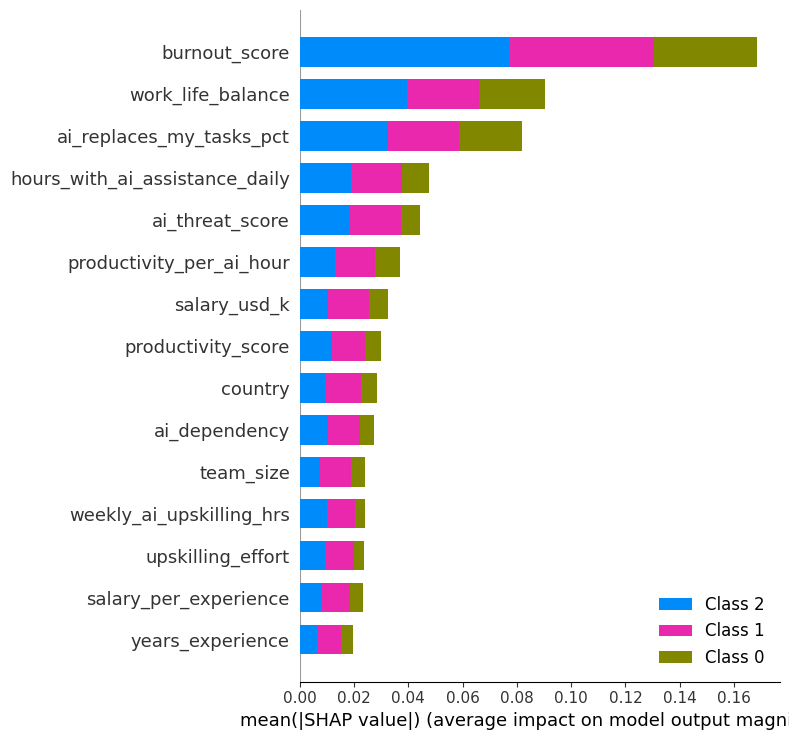

In [ ]:
algo_name = 'Random Forest'
i = 0

wScale = False if i == 1 else True
wSmote = False if i == 0 else True

model = getPipeline(
  get_base_algo(algo_name, i),
  wScale = wScale,
  wSmote = wSmote,
  fs='manual'
)

evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 18}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.6114
2. Test Accuracy            : 0.5022
3. Test F1-Score (Macro)    : 0.4876
4. Test Precision (Macro)   : 0.4821
5. Test Recall (Macro)      : 0.5792
6. CV Accuracy Mean (k=3) : 0.5057

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.2963    0.6400    0.4051        50
Medium/Neutral     0.6855    0.3893    0.4966       280
          High     0.4645    0.7083    0.5611       120

      accuracy                         0.5022       450
     macro avg     0.4821    0.5792    0.4876       450
  weighted avg     0.5833    0.5022    0.5036       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline

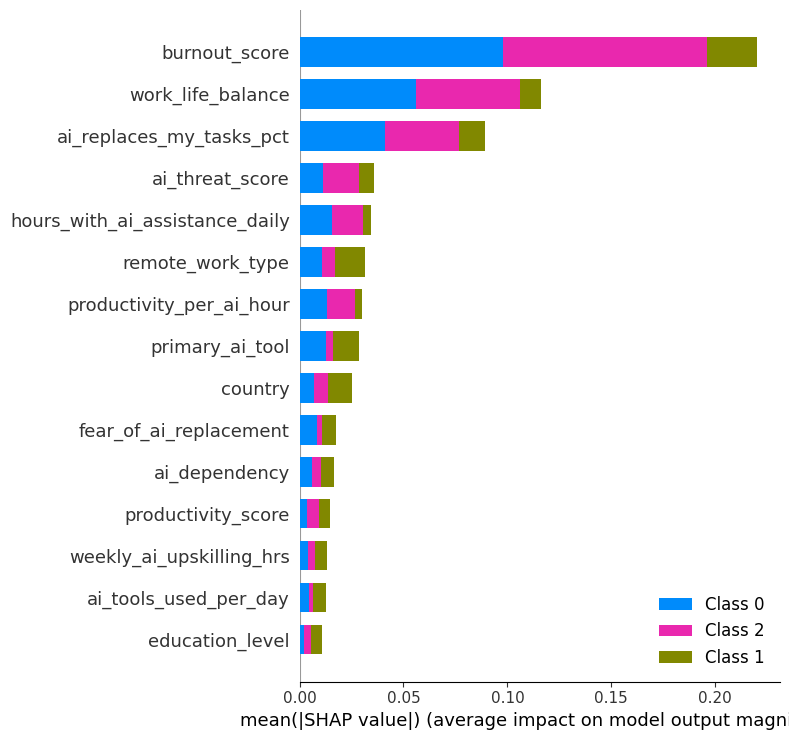

In [ ]:
i = 1

wScale = False if i == 1 else True
wSmote = False if i == 0 else True

model = getPipeline(
  get_base_algo(algo_name, i),
  wScale = wScale,
  wSmote = wSmote,
  fs='manual'
)

evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'n_estimators': 874, 'max_depth': 50, 'min_samples_split': 11, 'min_samples_leaf': 6}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.8971
2. Test Accuracy            : 0.6156
3. Test F1-Score (Macro)    : 0.5383
4. Test Precision (Macro)   : 0.5358
5. Test Recall (Macro)      : 0.5426
6. CV Accuracy Mean (k=3) : 0.5819

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3750    0.3600    0.3673        50
Medium/Neutral     0.7030    0.6679    0.6850       280
          High     0.5294    0.6000    0.5625       120

      accuracy                         0.6156       450
     macro avg     0.5358    0.5426    0.5383       450
  weighted avg     0.6203    0.6156    0.6170       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipelin

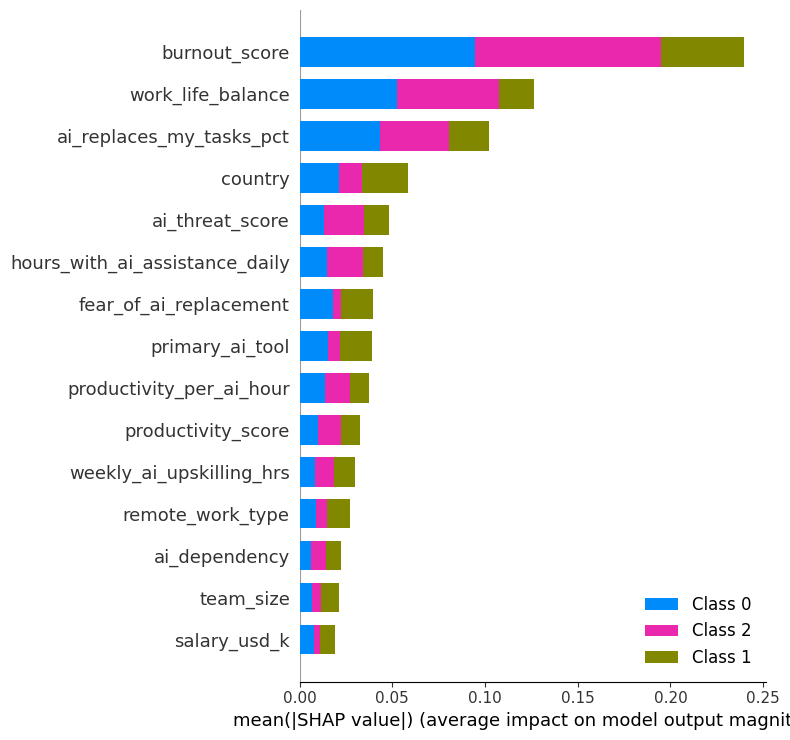

In [ ]:
i = 2

wScale = False if i == 1 else True
wSmote = False if i == 0 else True

model = getPipeline(
  get_base_algo(algo_name, i),
  wScale = wScale,
  wSmote = wSmote,
  fs='manual'
)

evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

#### RF

Parameter Terbaik
{'n_estimators': 873, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 2}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.9400
2. Test Accuracy            : 0.6644
3. Test F1-Score (Macro)    : 0.4429
4. Test Precision (Macro)   : 0.7029
5. Test Recall (Macro)      : 0.4350
6. CV Accuracy Mean (k=3) : 0.6476

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.8000    0.0800    0.1455        50
Medium/Neutral     0.6658    0.9250    0.7743       280
          High     0.6429    0.3000    0.4091       120

      accuracy                         0.6644       450
     macro avg     0.7029    0.4350    0.4429       450
  weighted avg     0.6746    0.6644    0.6070       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline

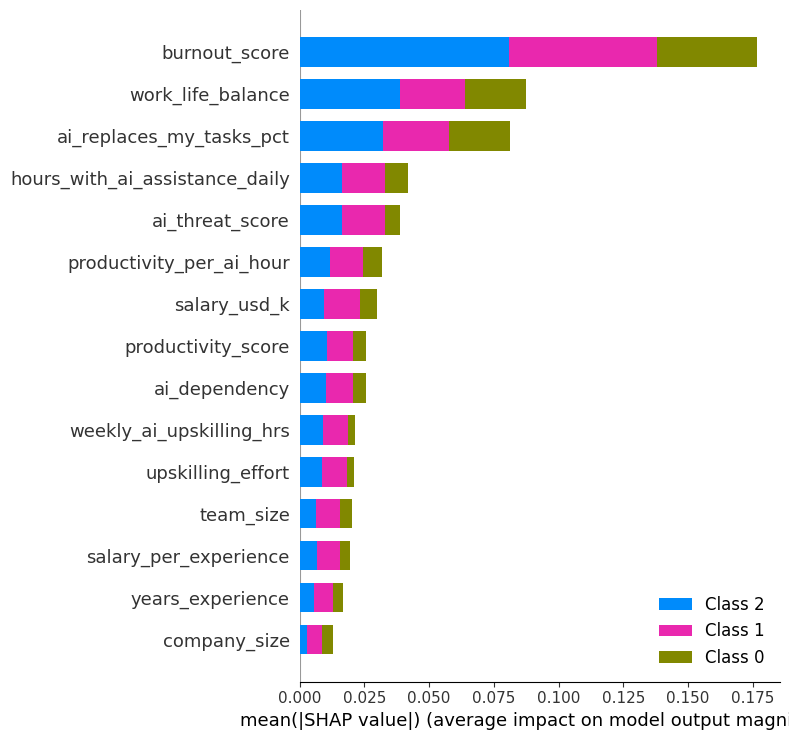

Parameter Terbaik
{'n_estimators': 384, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 18}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.6133
2. Test Accuracy            : 0.5156
3. Test F1-Score (Macro)    : 0.5039
4. Test Precision (Macro)   : 0.4967
5. Test Recall (Macro)      : 0.6028
6. CV Accuracy Mean (k=3) : 0.5171

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3125    0.7000    0.4321        50
Medium/Neutral     0.7000    0.4000    0.5091       280
          High     0.4775    0.7083    0.5705       120

      accuracy                         0.5156       450
     macro avg     0.4967    0.6028    0.5039       450
  weighted avg     0.5976    0.5156    0.5169       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipelin

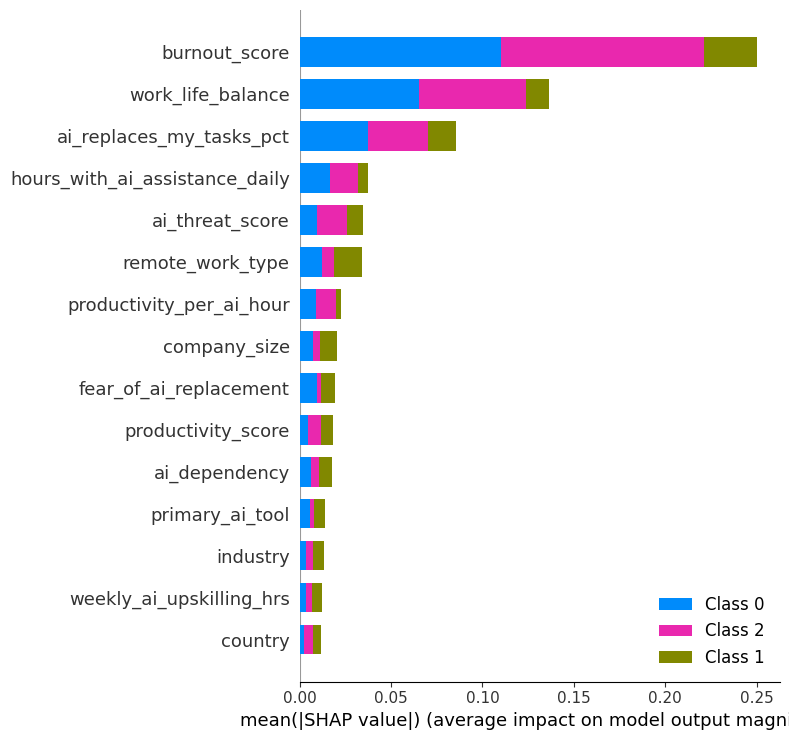

Parameter Terbaik
{'n_estimators': 290, 'max_depth': 30, 'min_samples_split': 7, 'min_samples_leaf': 6}
⏳ Sedang memproses evaluasi untuk Random Forest...

🏆 SUMMARY METRICS : RANDOM FOREST 🏆
1. Train Accuracy           : 0.8981
2. Test Accuracy            : 0.6067
3. Test F1-Score (Macro)    : 0.5315
4. Test Precision (Macro)   : 0.5302
5. Test Recall (Macro)      : 0.5347
6. CV Accuracy Mean (k=3) : 0.5724

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3830    0.3600    0.3711        50
Medium/Neutral     0.6929    0.6607    0.6764       280
          High     0.5147    0.5833    0.5469       120

      accuracy                         0.6067       450
     macro avg     0.5302    0.5347    0.5315       450
  weighted avg     0.6109    0.6067    0.6080       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline

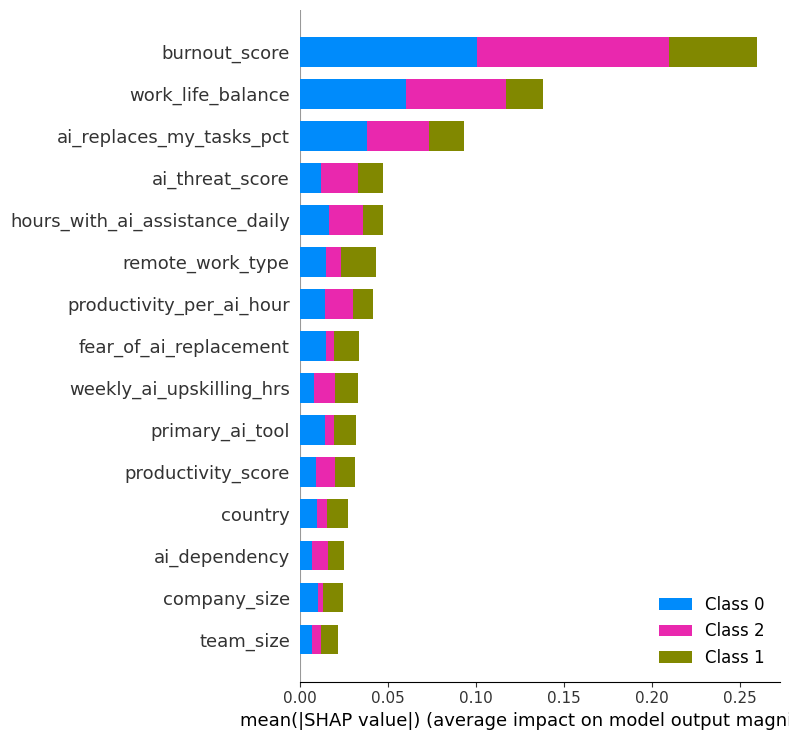

In [ ]:
algo_name = 'Random Forest'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### LR

Parameter Terbaik
{'C': 0.12600887333013197, 'solver': 'lbfgs'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.6676
2. Test Accuracy            : 0.6689
3. Test F1-Score (Macro)    : 0.4876
4. Test Precision (Macro)   : 0.6051
5. Test Recall (Macro)      : 0.4706
6. CV Accuracy Mean (k=3) : 0.6590

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5000    0.1200    0.1935        50
Medium/Neutral     0.6825    0.8750    0.7668       280
          High     0.6329    0.4167    0.5025       120

      accuracy                         0.6689       450
     macro avg     0.6051    0.4706    0.4876       450
  weighted avg     0.6490    0.6689    0.6326       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importan

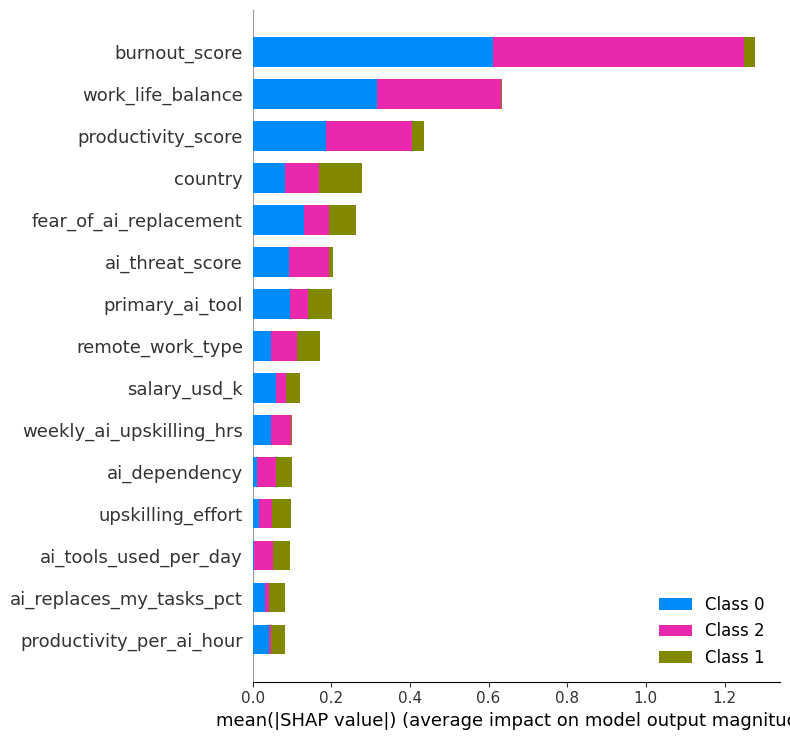

Parameter Terbaik
{'C': 0.31186935490258083, 'solver': 'lbfgs'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.5352
2. Test Accuracy            : 0.5356
3. Test F1-Score (Macro)    : 0.5181
4. Test Precision (Macro)   : 0.5053
5. Test Recall (Macro)      : 0.6024
6. CV Accuracy Mean (k=3) : 0.4857

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3271    0.7000    0.4459        50
Medium/Neutral     0.7072    0.4571    0.5553       280
          High     0.4815    0.6500    0.5532       120

      accuracy                         0.5356       450
     macro avg     0.5053    0.6024    0.5181       450
  weighted avg     0.6048    0.5356    0.5426       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importan

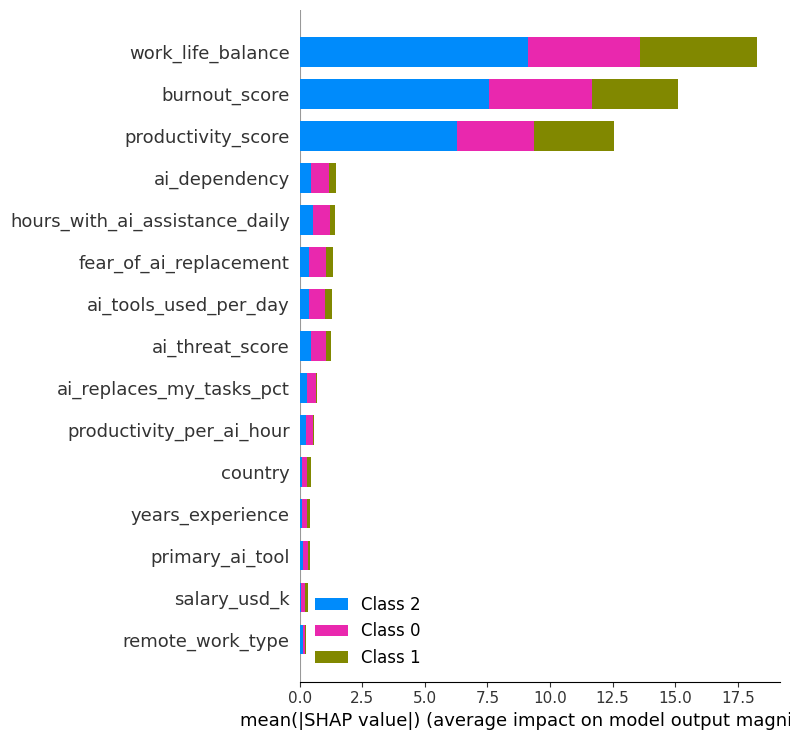

Parameter Terbaik
{'C': 0.06157621574057401, 'solver': 'lbfgs'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.5495
2. Test Accuracy            : 0.5422
3. Test F1-Score (Macro)    : 0.5350
4. Test Precision (Macro)   : 0.5271
5. Test Recall (Macro)      : 0.6460
6. CV Accuracy Mean (k=3) : 0.5000

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3540    0.8000    0.4908        50
Medium/Neutral     0.7468    0.4214    0.5388       280
          High     0.4804    0.7167    0.5753       120

      accuracy                         0.5422       450
     macro avg     0.5271    0.6460    0.5350       450
  weighted avg     0.6321    0.5422    0.5432       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importan

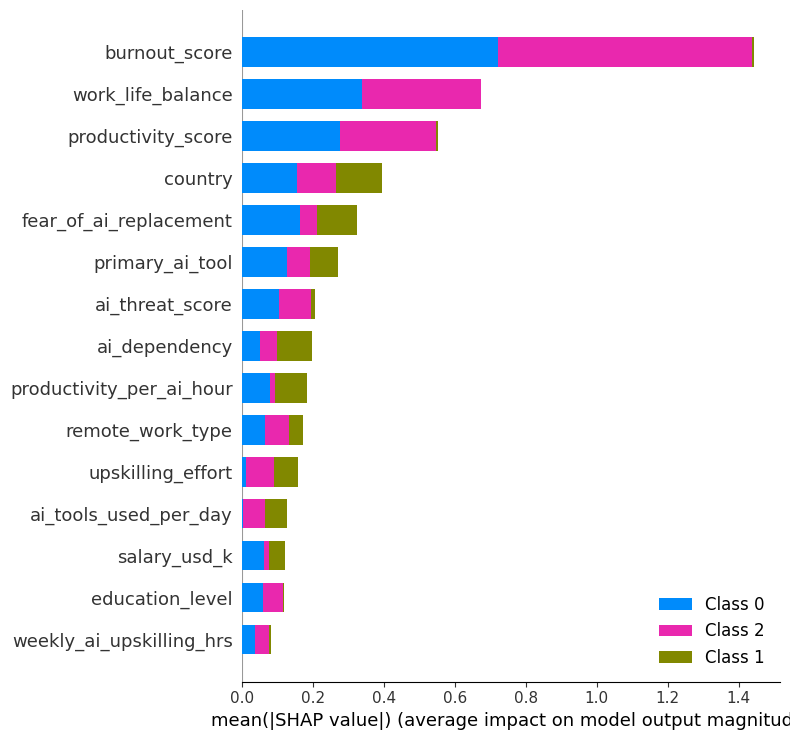

In [ ]:
algo_name = 'Logistic Regression'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'C': 1.1740816713136866, 'solver': 'lbfgs'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.6733
2. Test Accuracy            : 0.6733
3. Test F1-Score (Macro)    : 0.4976
4. Test Precision (Macro)   : 0.6225
5. Test Recall (Macro)      : 0.4768
6. CV Accuracy Mean (k=3) : 0.6410

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5385    0.1400    0.2222        50
Medium/Neutral     0.6842    0.8821    0.7707       280
          High     0.6447    0.4083    0.5000       120

      accuracy                         0.6733       450
     macro avg     0.6225    0.4768    0.4976       450
  weighted avg     0.6575    0.6733    0.6376       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importanc

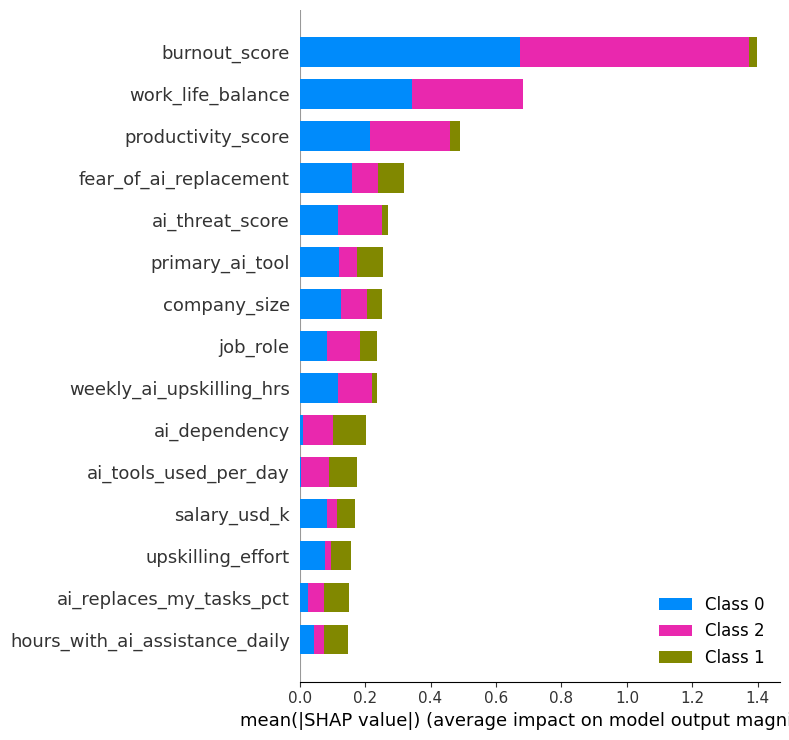

Parameter Terbaik
{'C': 0.0005634188797104414, 'solver': 'liblinear'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.4267
2. Test Accuracy            : 0.4600
3. Test F1-Score (Macro)    : 0.4584
4. Test Precision (Macro)   : 0.4861
5. Test Recall (Macro)      : 0.6147
6. CV Accuracy Mean (k=3) : 0.4095

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.2837    0.8000    0.4188        50
Medium/Neutral     0.7228    0.2607    0.3832       280
          High     0.4519    0.7833    0.5732       120

      accuracy                         0.4600       450
     macro avg     0.4861    0.6147    0.4584       450
  weighted avg     0.6018    0.4600    0.4378       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Im

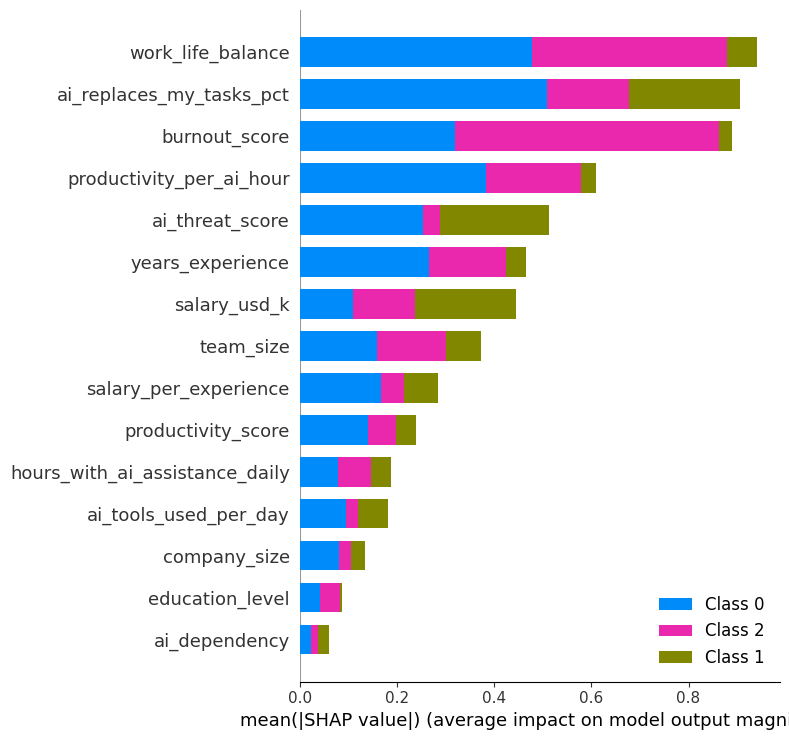

Parameter Terbaik
{'C': 0.12691005083980308, 'solver': 'lbfgs'}
⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.5438
2. Test Accuracy            : 0.5333
3. Test F1-Score (Macro)    : 0.5238
4. Test Precision (Macro)   : 0.5138
5. Test Recall (Macro)      : 0.6279
6. CV Accuracy Mean (k=3) : 0.5067

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3391    0.7800    0.4727        50
Medium/Neutral     0.7229    0.4286    0.5381       280
          High     0.4793    0.6750    0.5606       120

      accuracy                         0.5333       450
     macro avg     0.5138    0.6279    0.5238       450
  weighted avg     0.6153    0.5333    0.5368       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importan

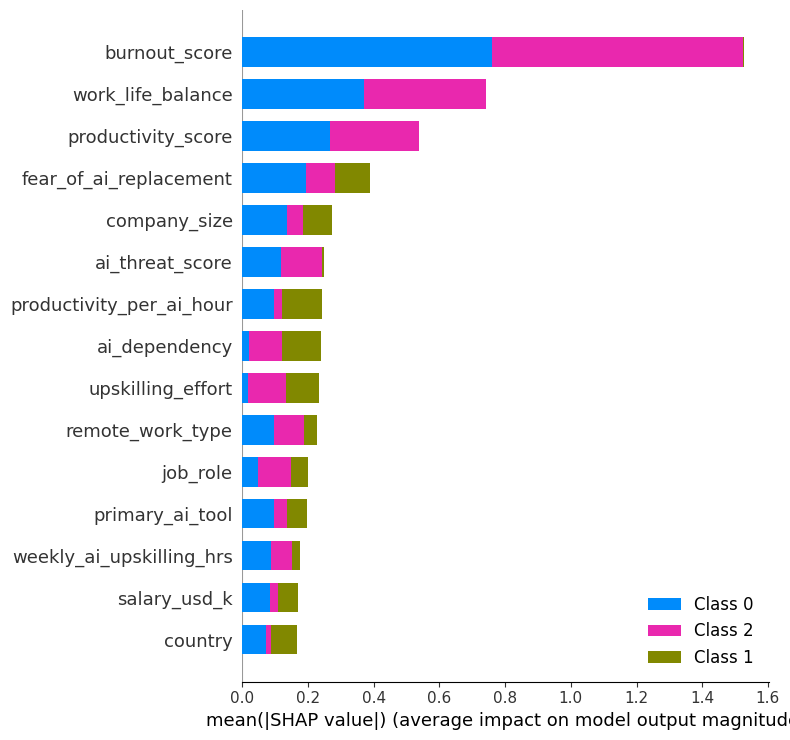

In [ ]:
algo_name = 'Logistic Regression'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### CatBoost

Parameter Terbaik
{'iterations': 110, 'learning_rate': 0.21751661643618675, 'depth': 4, 'l2_leaf_reg': 7.992042433893281}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 0.7876
2. Test Accuracy            : 0.6644
3. Test F1-Score (Macro)    : 0.5135
4. Test Precision (Macro)   : 0.6075
5. Test Recall (Macro)      : 0.4885
6. CV Accuracy Mean (k=3) : 0.6400

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5263    0.2000    0.2899        50
Medium/Neutral     0.6838    0.8571    0.7607       280
          High     0.6125    0.4083    0.4900       120

      accuracy                         0.6644       450
     macro avg     0.6075    0.4885    0.5135       450
  weighted avg     0.6473    0.6644    0.6362       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari 

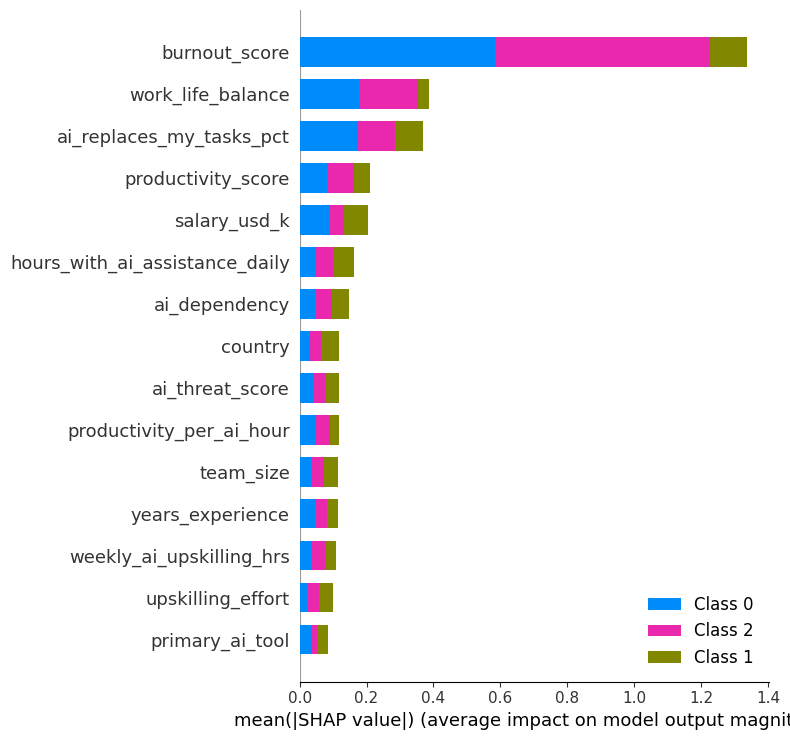

Parameter Terbaik
{'iterations': 135, 'learning_rate': 0.0053352059844099416, 'depth': 7, 'l2_leaf_reg': 2.565351510392949}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 0.5295
2. Test Accuracy            : 0.4444
3. Test F1-Score (Macro)    : 0.4463
4. Test Precision (Macro)   : 0.4621
5. Test Recall (Macro)      : 0.5913
6. CV Accuracy Mean (k=3) : 0.4600

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.2955    0.7800    0.4286        50
Medium/Neutral     0.6697    0.2607    0.3753       280
          High     0.4211    0.7333    0.5350       120

      accuracy                         0.4444       450
     macro avg     0.4621    0.5913    0.4463       450
  weighted avg     0.5618    0.4444    0.4238       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dar

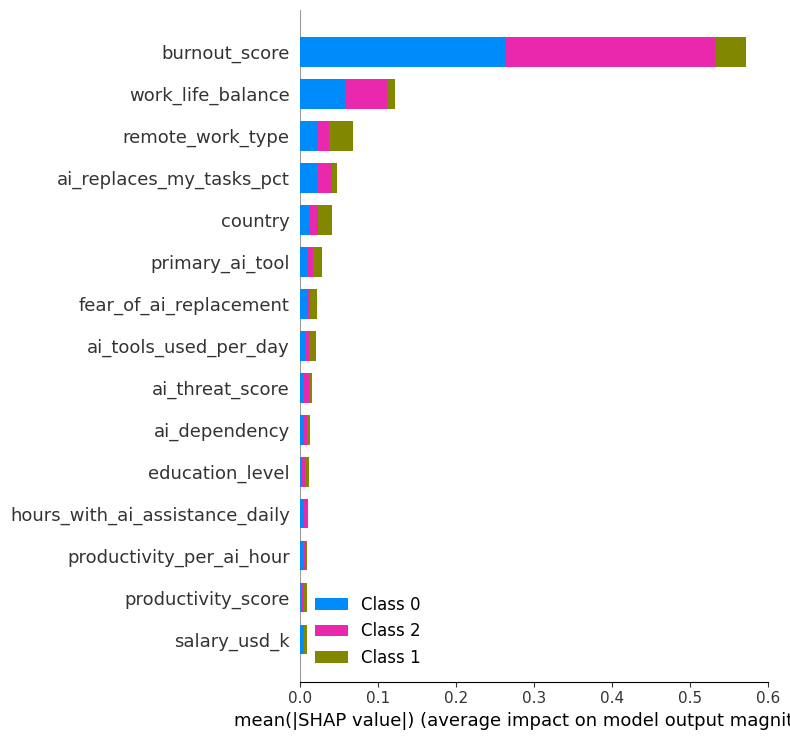

Parameter Terbaik
{'iterations': 611, 'learning_rate': 0.010781119597332514, 'depth': 5, 'l2_leaf_reg': 7.44038308212079}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 0.6590
2. Test Accuracy            : 0.5667
3. Test F1-Score (Macro)    : 0.5255
4. Test Precision (Macro)   : 0.5102
5. Test Recall (Macro)      : 0.5698
6. CV Accuracy Mean (k=3) : 0.5371

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3250    0.5200    0.4000        50
Medium/Neutral     0.7056    0.5393    0.6113       280
          High     0.5000    0.6500    0.5652       120

      accuracy                         0.5667       450
     macro avg     0.5102    0.5698    0.5255       450
  weighted avg     0.6085    0.5667    0.5756       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari 

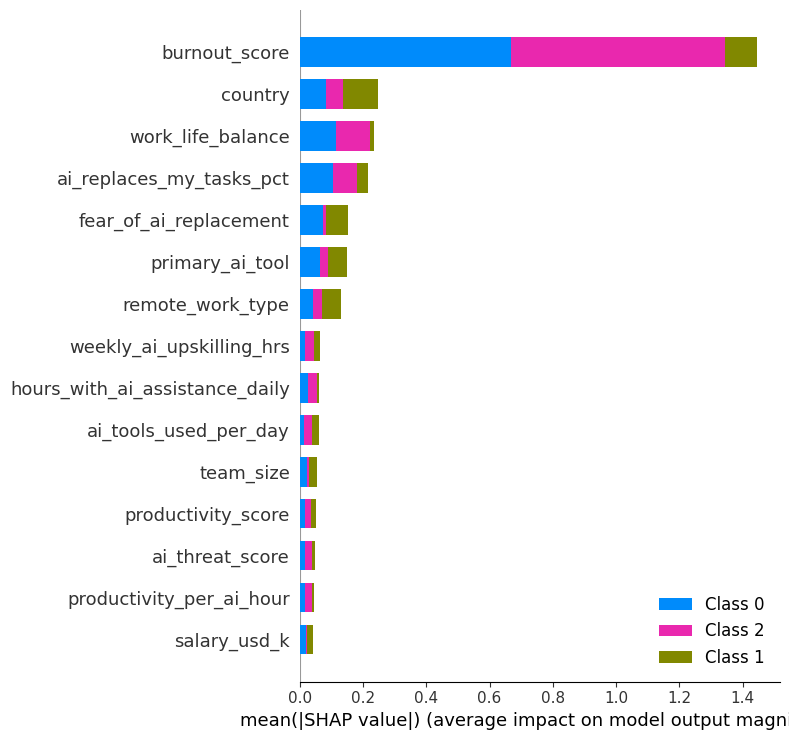

In [ ]:
algo_name = 'CatBoost'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'iterations': 622, 'learning_rate': 0.20879037025421512, 'depth': 4, 'l2_leaf_reg': 2.4414031284562516}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6489
3. Test F1-Score (Macro)    : 0.5091
4. Test Precision (Macro)   : 0.5827
5. Test Recall (Macro)      : 0.4856
6. CV Accuracy Mean (k=3) : 0.6029

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5000    0.2200    0.3056        50
Medium/Neutral     0.6784    0.8286    0.7460       280
          High     0.5698    0.4083    0.4757       120

      accuracy                         0.6489       450
     macro avg     0.5827    0.4856    0.5091       450
  weighted avg     0.6296    0.6489    0.6250       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari

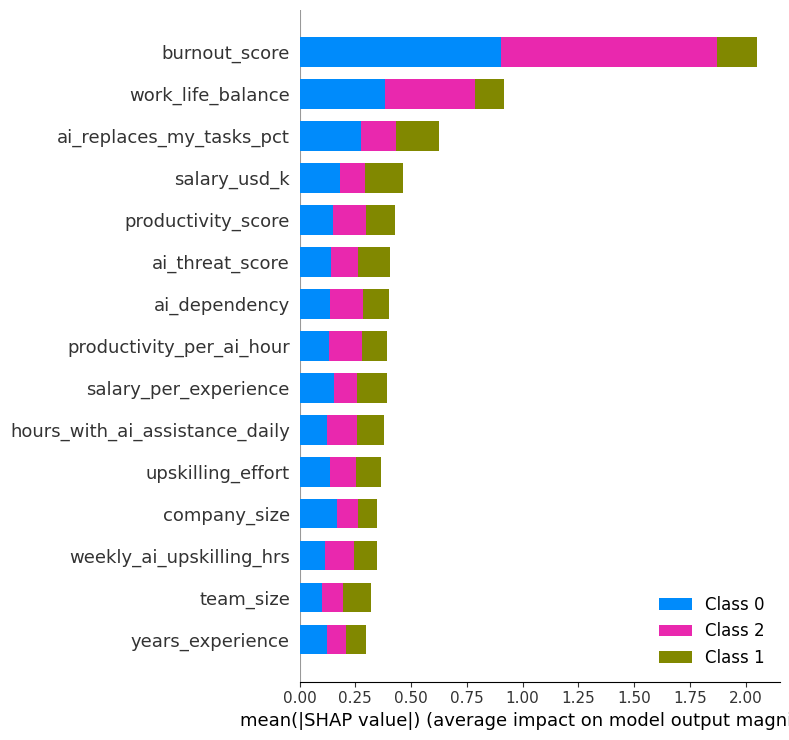

Parameter Terbaik
{'iterations': 926, 'learning_rate': 0.06026754150512769, 'depth': 10, 'l2_leaf_reg': 1.0932287548164599}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 0.9790
2. Test Accuracy            : 0.6178
3. Test F1-Score (Macro)    : 0.5209
4. Test Precision (Macro)   : 0.5387
5. Test Recall (Macro)      : 0.5099
6. CV Accuracy Mean (k=3) : 0.5638

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4167    0.3000    0.3488        50
Medium/Neutral     0.6824    0.7214    0.7014       280
          High     0.5169    0.5083    0.5126       120

      accuracy                         0.6178       450
     macro avg     0.5387    0.5099    0.5209       450
  weighted avg     0.6088    0.6178    0.6119       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dar

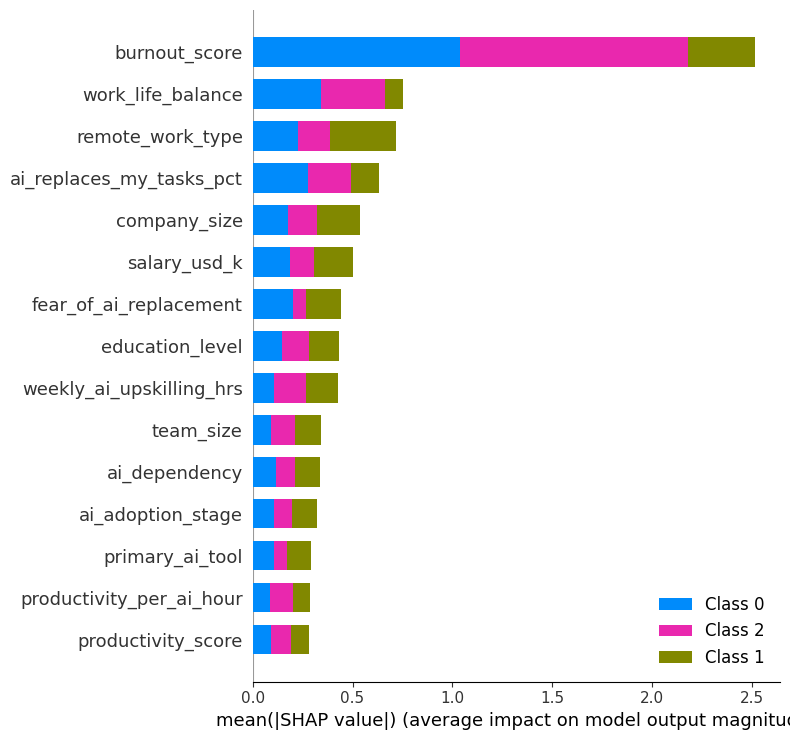

Parameter Terbaik
{'iterations': 880, 'learning_rate': 0.003624533706355021, 'depth': 4, 'l2_leaf_reg': 7.100029029532296}
⏳ Sedang memproses evaluasi untuk CatBoost...

🏆 SUMMARY METRICS : CATBOOST 🏆
1. Train Accuracy           : 0.5648
2. Test Accuracy            : 0.5111
3. Test F1-Score (Macro)    : 0.4952
4. Test Precision (Macro)   : 0.4899
5. Test Recall (Macro)      : 0.5879
6. CV Accuracy Mean (k=3) : 0.5076

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.2920    0.6600    0.4049        50
Medium/Neutral     0.6975    0.4036    0.5113       280
          High     0.4800    0.7000    0.5695       120

      accuracy                         0.5111       450
     macro avg     0.4899    0.5879    0.4952       450
  weighted avg     0.5945    0.5111    0.5150       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari

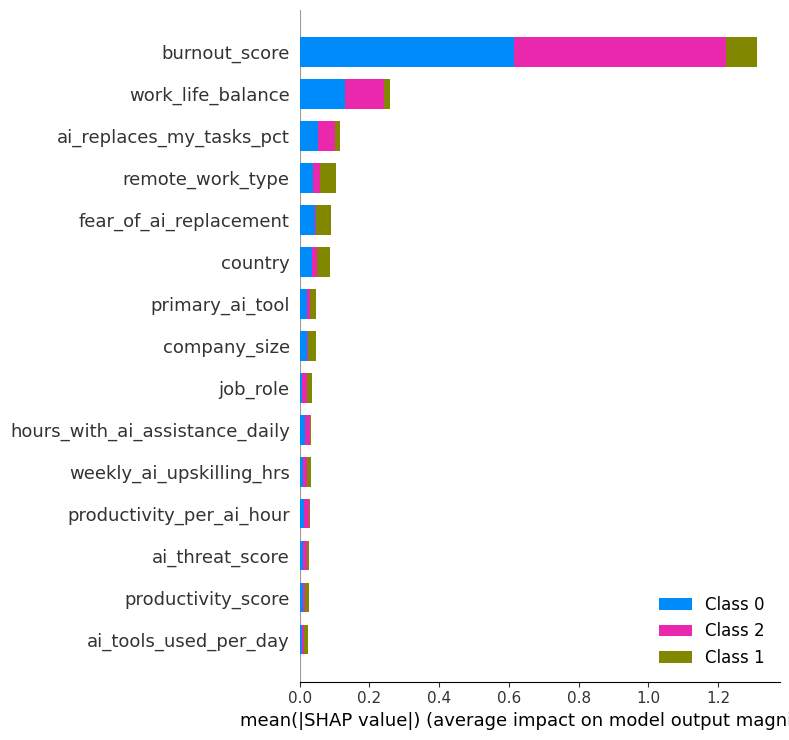

In [ ]:
algo_name = 'CatBoost'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### XGBoost

Parameter Terbaik
{'n_estimators': 930, 'learning_rate': 0.21924570391692522, 'max_depth': 7, 'subsample': 0.7809048443111638, 'colsample_bytree': 0.9627355533796078}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6111
3. Test F1-Score (Macro)    : 0.4552
4. Test Precision (Macro)   : 0.4967
5. Test Recall (Macro)      : 0.4426
6. CV Accuracy Mean (k=3) : 0.5981

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3200    0.1600    0.2133        50
Medium/Neutral     0.6588    0.7929    0.7196       280
          High     0.5114    0.3750    0.4327       120

      accuracy                         0.6111       450
     macro avg     0.4967    0.4426    0.4552       450
  weighted avg     0.5818    0.6111    0.5868       450

-----------------------------------------------

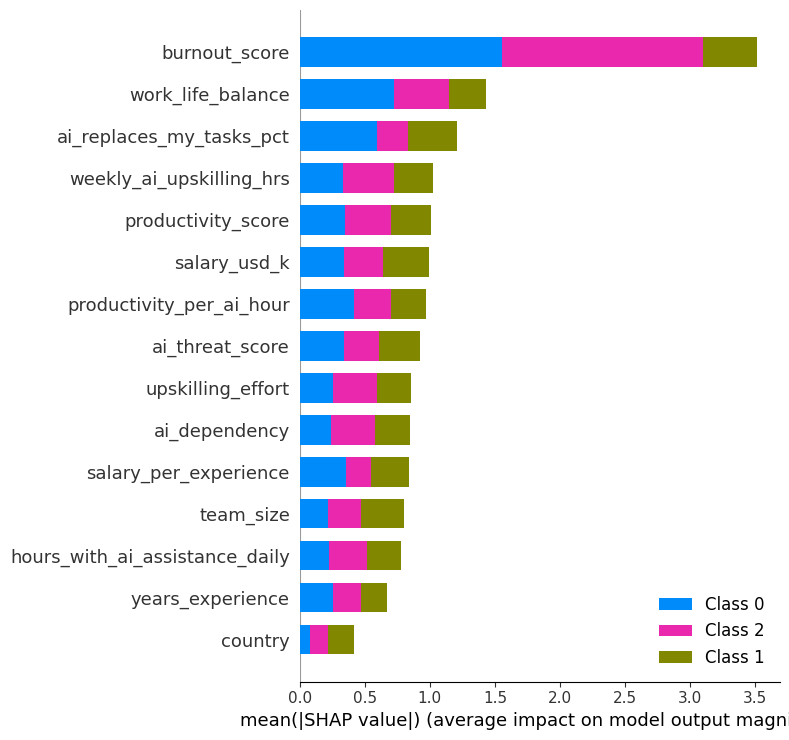

Parameter Terbaik
{'n_estimators': 779, 'learning_rate': 0.012971494264034423, 'max_depth': 8, 'subsample': 0.5253161028324531, 'colsample_bytree': 0.7058531539503271}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6578
3. Test F1-Score (Macro)    : 0.5250
4. Test Precision (Macro)   : 0.5896
5. Test Recall (Macro)      : 0.5031
6. CV Accuracy Mean (k=3) : 0.6114

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5000    0.2200    0.3056        50
Medium/Neutral     0.6930    0.8143    0.7488       280
          High     0.5758    0.4750    0.5205       120

      accuracy                         0.6578       450
     macro avg     0.5896    0.5031    0.5250       450
  weighted avg     0.6403    0.6578    0.6387       450

----------------------------------------------

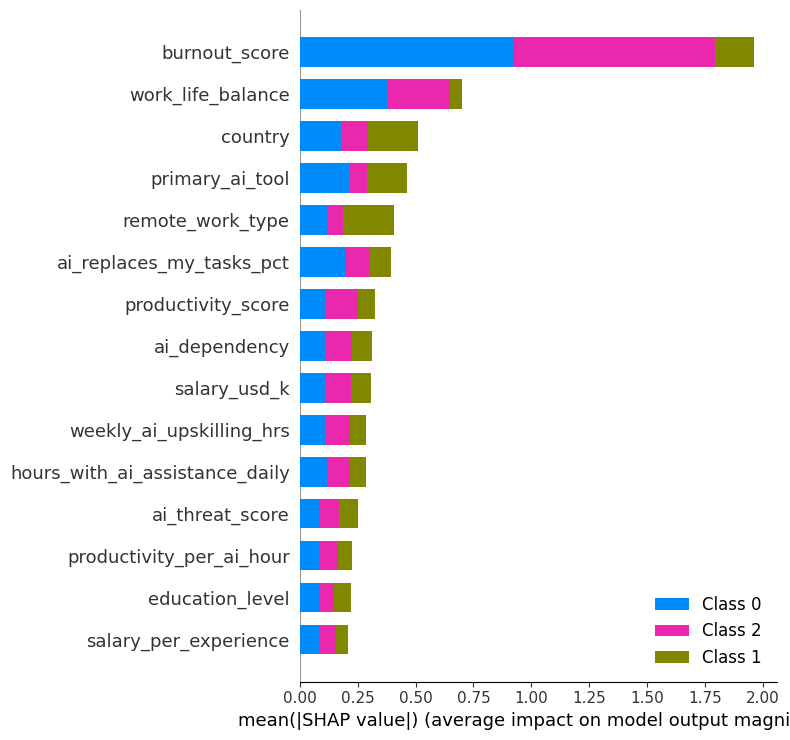

Parameter Terbaik
{'n_estimators': 891, 'learning_rate': 0.004106658569963658, 'max_depth': 3, 'subsample': 0.9422977190401586, 'colsample_bytree': 0.689410135110179}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 0.6933
2. Test Accuracy            : 0.5844
3. Test F1-Score (Macro)    : 0.5455
4. Test Precision (Macro)   : 0.5284
5. Test Recall (Macro)      : 0.5918
6. CV Accuracy Mean (k=3) : 0.5629

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3500    0.5600    0.4308        50
Medium/Neutral     0.7222    0.5571    0.6290       280
          High     0.5130    0.6583    0.5766       120

      accuracy                         0.5844       450
     macro avg     0.5284    0.5918    0.5455       450
  weighted avg     0.6251    0.5844    0.5930       450

-----------------------------------------------

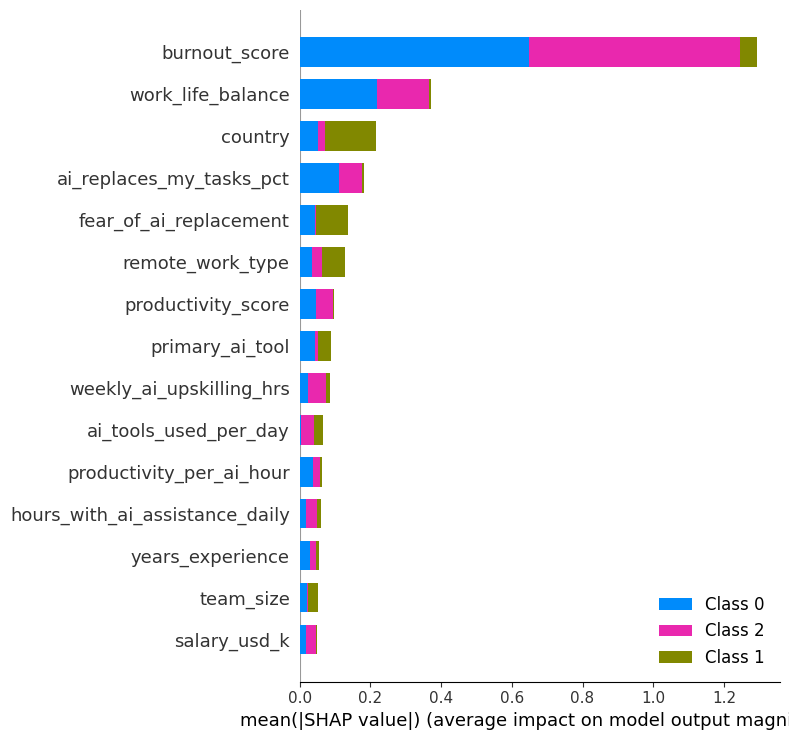

In [ ]:
algo_name = 'XGBoost'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'n_estimators': 562, 'learning_rate': 0.1455427473796827, 'max_depth': 8, 'subsample': 0.6591697727922595, 'colsample_bytree': 0.845366874989629}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6400
3. Test F1-Score (Macro)    : 0.4959
4. Test Precision (Macro)   : 0.5517
5. Test Recall (Macro)      : 0.4770
6. CV Accuracy Mean (k=3) : 0.6124

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4167    0.2000    0.2703        50
Medium/Neutral     0.6766    0.8143    0.7391       280
          High     0.5618    0.4167    0.4785       120

      accuracy                         0.6400       450
     macro avg     0.5517    0.4770    0.4959       450
  weighted avg     0.6171    0.6400    0.6175       450

-------------------------------------------------

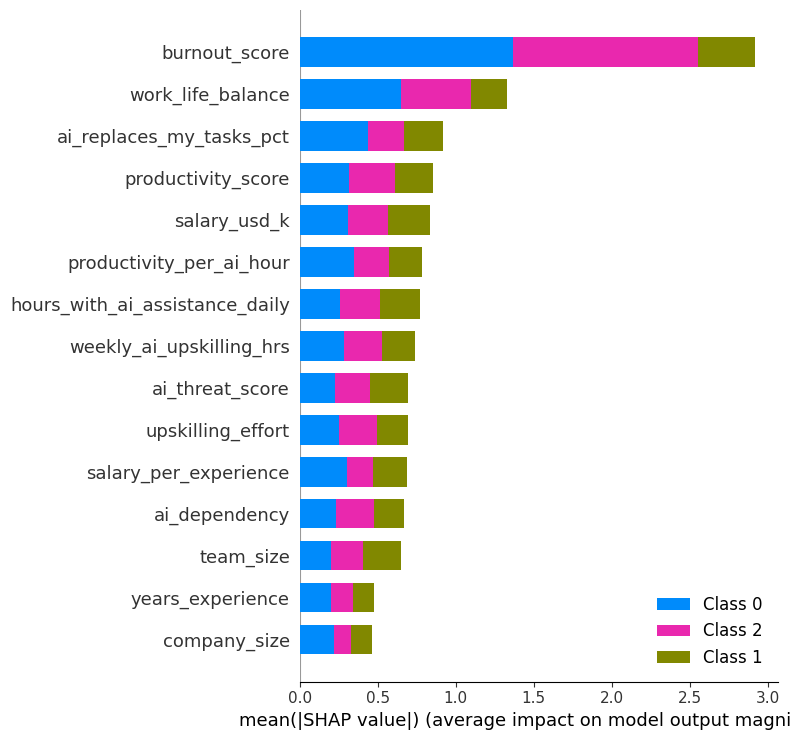

Parameter Terbaik
{'n_estimators': 407, 'learning_rate': 0.022014170327343208, 'max_depth': 3, 'subsample': 0.9493441874731455, 'colsample_bytree': 0.6584176056288116}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 0.7971
2. Test Accuracy            : 0.5978
3. Test F1-Score (Macro)    : 0.4996
4. Test Precision (Macro)   : 0.5108
5. Test Recall (Macro)      : 0.4913
6. CV Accuracy Mean (k=3) : 0.5943

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3659    0.3000    0.3297        50
Medium/Neutral     0.6667    0.7071    0.6863       280
          High     0.5000    0.4667    0.4828       120

      accuracy                         0.5978       450
     macro avg     0.5108    0.4913    0.4996       450
  weighted avg     0.5888    0.5978    0.5924       450

----------------------------------------------

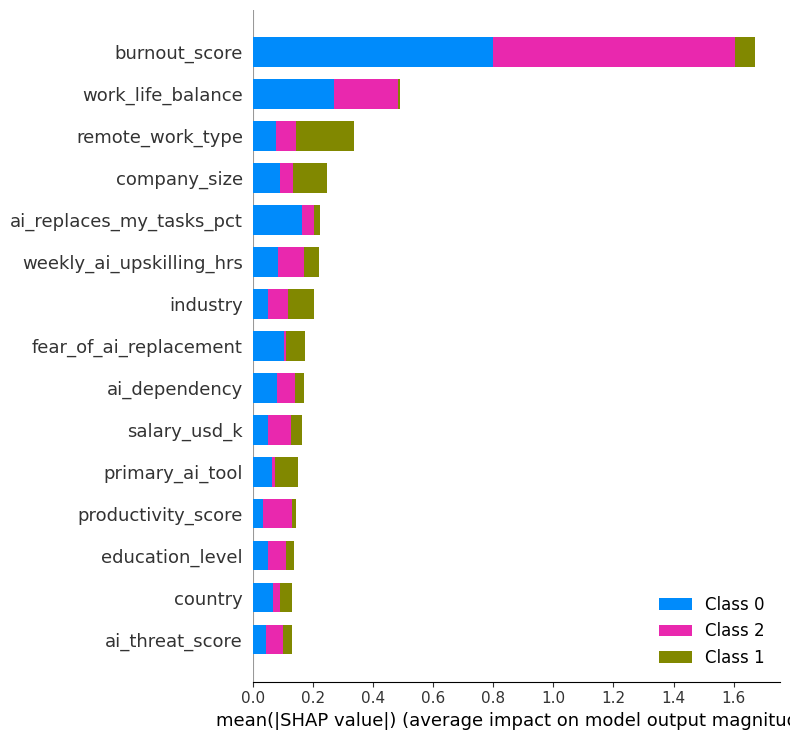

Parameter Terbaik
{'n_estimators': 384, 'learning_rate': 0.0016428953735723067, 'max_depth': 7, 'subsample': 0.7960003645466258, 'colsample_bytree': 0.5273961534343556}
⏳ Sedang memproses evaluasi untuk XGBoost...

🏆 SUMMARY METRICS : XGBOOST 🏆
1. Train Accuracy           : 0.9029
2. Test Accuracy            : 0.6067
3. Test F1-Score (Macro)    : 0.5375
4. Test Precision (Macro)   : 0.5291
5. Test Recall (Macro)      : 0.5502
6. CV Accuracy Mean (k=3) : 0.5771

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3438    0.4400    0.3860        50
Medium/Neutral     0.6981    0.6607    0.6789       280
          High     0.5455    0.5500    0.5477       120

      accuracy                         0.6067       450
     macro avg     0.5291    0.5502    0.5375       450
  weighted avg     0.6180    0.6067    0.6114       450

---------------------------------------------

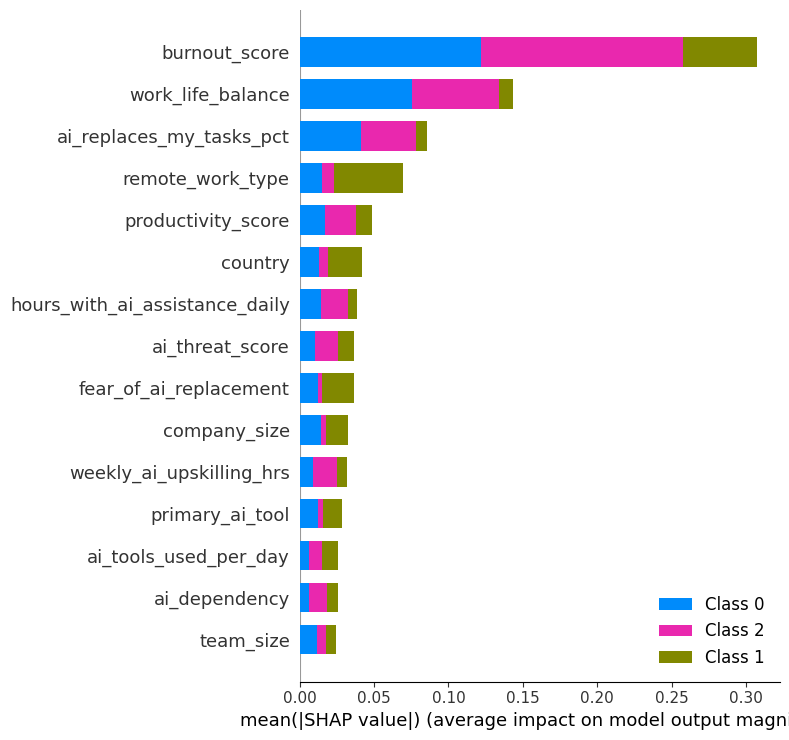

In [ ]:
algo_name = 'XGBoost'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### LightGBM

Parameter Terbaik
{'n_estimators': 813, 'learning_rate': 0.13854667115225974, 'num_leaves': 76, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 0.7256494499257813, 'colsample_bytree': 0.9316782524656649}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6333
3. Test F1-Score (Macro)    : 0.4932
4. Test Precision (Macro)   : 0.5248
5. Test Recall (Macro)      : 0.4806
6. CV Accuracy Mean (k=3) : 0.6038

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3333    0.1800    0.2338        50
Medium/Neutral     0.6834    0.7786    0.7279       280
          High     0.5577    0.4833    0.5179       120

      accuracy                         0.6333       450
     macro avg     0.5248    0.4806    0.4932       450
  weighted avg     0.6110    0.6333    0.6170       450

-

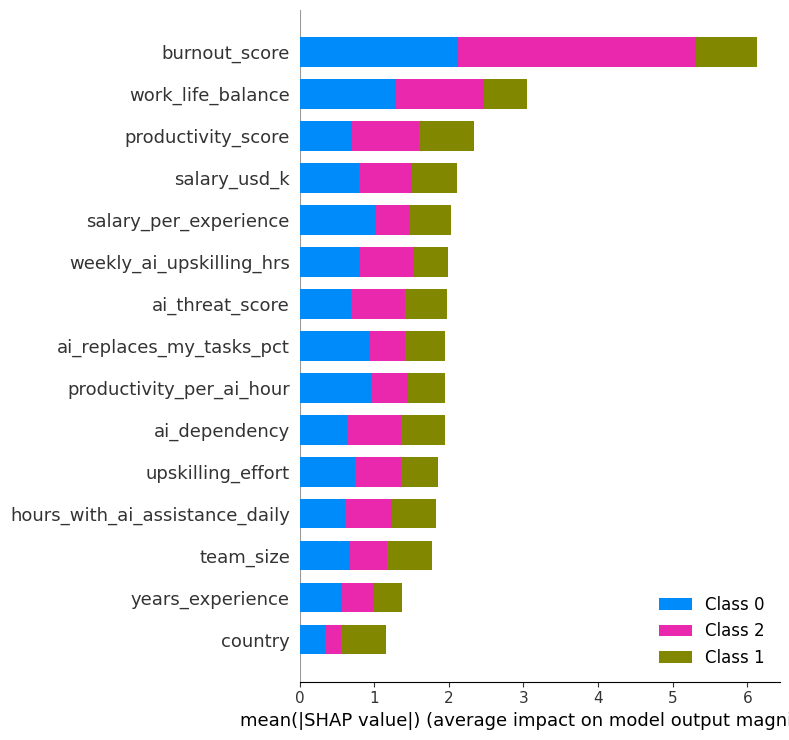

Parameter Terbaik
{'n_estimators': 633, 'learning_rate': 0.0013033567475147442, 'num_leaves': 69, 'max_depth': 4, 'min_child_samples': 12, 'subsample': 0.9744427686266666, 'colsample_bytree': 0.9828160165372797}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 0.6590
2. Test Accuracy            : 0.5222
3. Test F1-Score (Macro)    : 0.4950
4. Test Precision (Macro)   : 0.4820
5. Test Recall (Macro)      : 0.5576
6. CV Accuracy Mean (k=3) : 0.5333

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.2990    0.5800    0.3946        50
Medium/Neutral     0.6753    0.4679    0.5527       280
          High     0.4717    0.6250    0.5376       120

      accuracy                         0.5222       450
     macro avg     0.4820    0.5576    0.4950       450
  weighted avg     0.5792    0.5222    0.5311       450



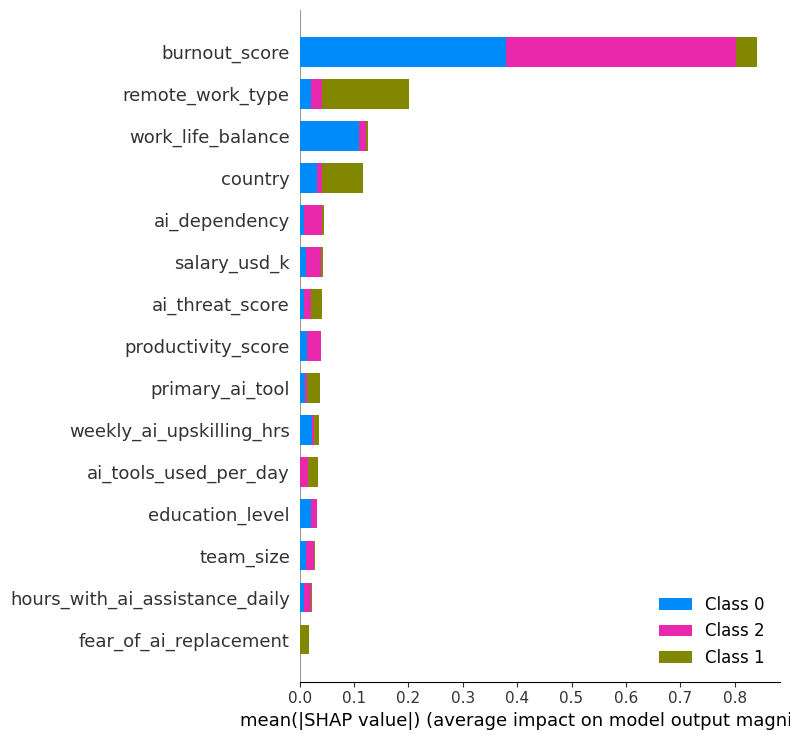

Parameter Terbaik
{'n_estimators': 915, 'learning_rate': 0.0013049867467967928, 'num_leaves': 89, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.9922375964136952, 'colsample_bytree': 0.5030114997999782}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 0.7962
2. Test Accuracy            : 0.6267
3. Test F1-Score (Macro)    : 0.5439
4. Test Precision (Macro)   : 0.5435
5. Test Recall (Macro)      : 0.5445
6. CV Accuracy Mean (k=3) : 0.6057

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3654    0.3800    0.3725        50
Medium/Neutral     0.7011    0.7036    0.7023       280
          High     0.5641    0.5500    0.5570       120

      accuracy                         0.6267       450
     macro avg     0.5435    0.5445    0.5439       450
  weighted avg     0.6272    0.6267    0.6269       450


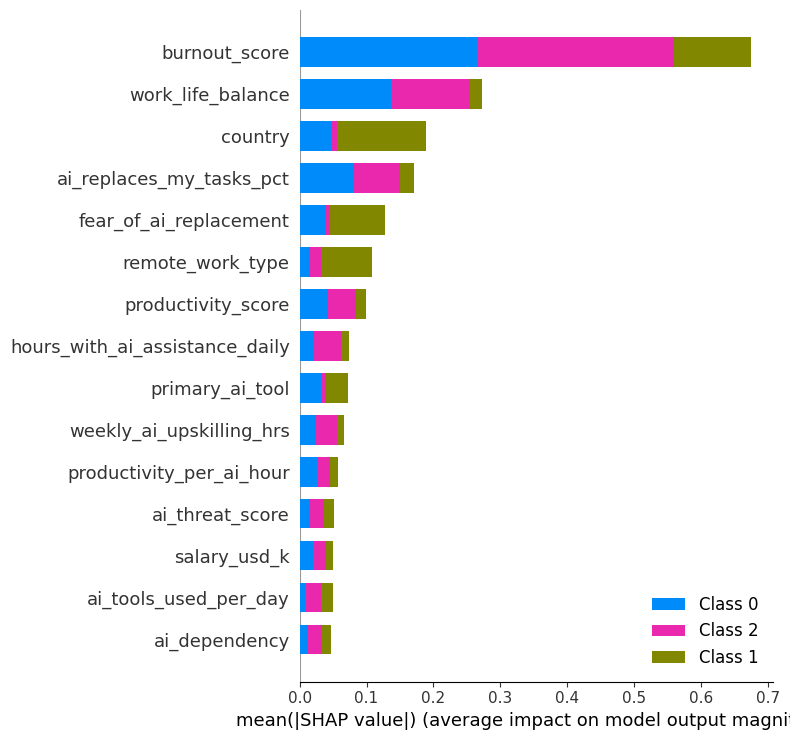

In [ ]:
algo_name = 'LightGBM'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'n_estimators': 489, 'learning_rate': 0.009563365366539319, 'num_leaves': 76, 'max_depth': 12, 'min_child_samples': 45, 'subsample': 0.7729047891830829, 'colsample_bytree': 0.8504871491718292}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 0.9067
2. Test Accuracy            : 0.6489
3. Test F1-Score (Macro)    : 0.5011
4. Test Precision (Macro)   : 0.5968
5. Test Recall (Macro)      : 0.4770
6. CV Accuracy Mean (k=3) : 0.6238

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5556    0.2000    0.2941        50
Medium/Neutral     0.6753    0.8393    0.7484       280
          High     0.5595    0.3917    0.4608       120

      accuracy                         0.6489       450
     macro avg     0.5968    0.4770    0.5011       450
  weighted avg     0.6311    0.6489    0.6212       450



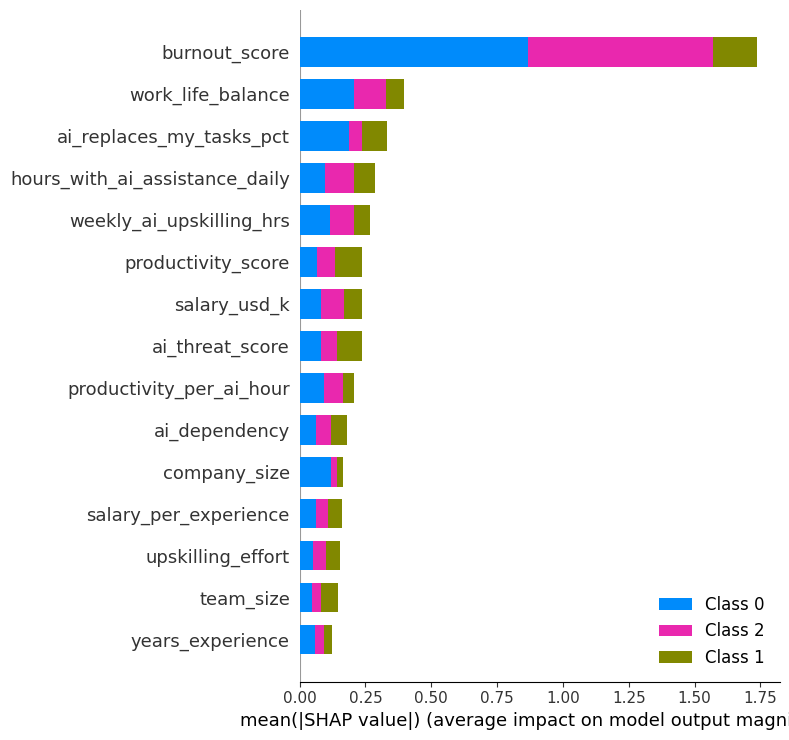

Parameter Terbaik
{'n_estimators': 553, 'learning_rate': 0.21254315070658844, 'num_leaves': 88, 'max_depth': 12, 'min_child_samples': 12, 'subsample': 0.6482375347651906, 'colsample_bytree': 0.5183616312167109}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 0.9829
2. Test Accuracy            : 0.6178
3. Test F1-Score (Macro)    : 0.4891
4. Test Precision (Macro)   : 0.5506
5. Test Recall (Macro)      : 0.4690
6. CV Accuracy Mean (k=3) : 0.5990

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5000    0.2200    0.3056        50
Medium/Neutral     0.6667    0.7786    0.7183       280
          High     0.4851    0.4083    0.4434       120

      accuracy                         0.6178       450
     macro avg     0.5506    0.4690    0.4891       450
  weighted avg     0.5997    0.6178    0.5991       450

-

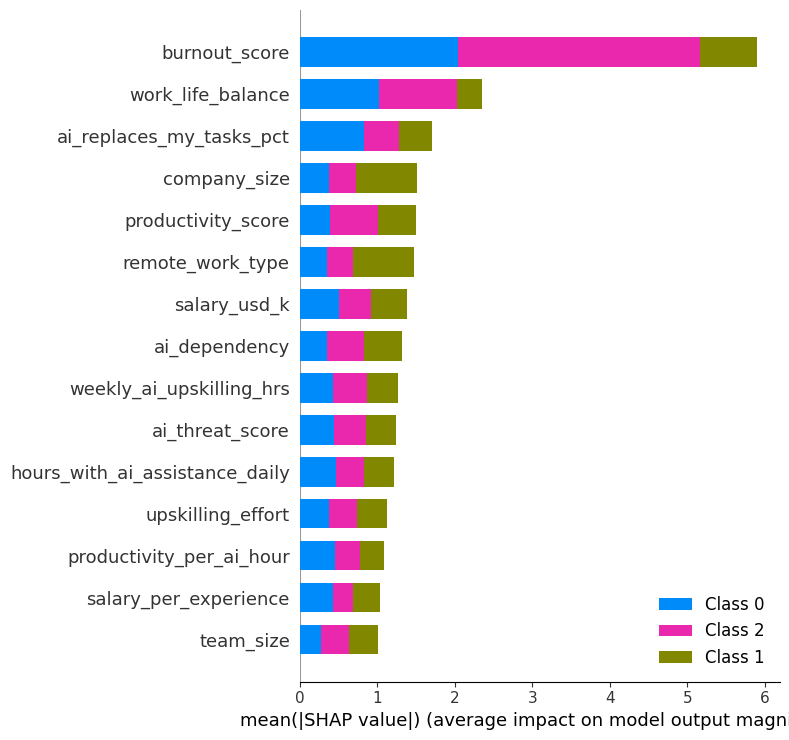

Parameter Terbaik
{'n_estimators': 100, 'learning_rate': 0.01688214082033666, 'num_leaves': 42, 'max_depth': 6, 'min_child_samples': 48, 'subsample': 0.9538677753235226, 'colsample_bytree': 0.6410779550000822}
⏳ Sedang memproses evaluasi untuk LightGBM...

🏆 SUMMARY METRICS : LIGHTGBM 🏆
1. Train Accuracy           : 0.7524
2. Test Accuracy            : 0.5956
3. Test F1-Score (Macro)    : 0.5305
4. Test Precision (Macro)   : 0.5207
5. Test Recall (Macro)      : 0.5459
6. CV Accuracy Mean (k=3) : 0.6019

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3333    0.4400    0.3793        50
Medium/Neutral     0.6885    0.6393    0.6630       280
          High     0.5403    0.5583    0.5492       120

      accuracy                         0.5956       450
     macro avg     0.5207    0.5459    0.5305       450
  weighted avg     0.6095    0.5956    0.6011       450

--

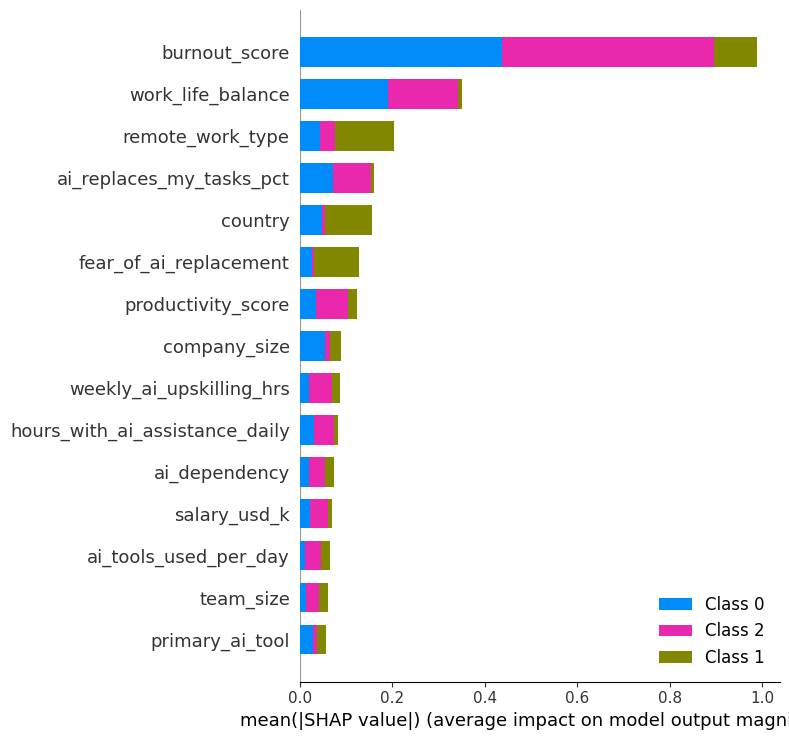

In [ ]:
algo_name = 'LightGBM'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### Extra Tree

Parameter Terbaik
{'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.8467
2. Test Accuracy            : 0.6733
3. Test F1-Score (Macro)    : 0.4918
4. Test Precision (Macro)   : 0.6386
5. Test Recall (Macro)      : 0.4705
6. CV Accuracy Mean (k=3) : 0.6410

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5833    0.1400    0.2258        50
Medium/Neutral     0.6802    0.8964    0.7735       280
          High     0.6522    0.3750    0.4762       120

      accuracy                         0.6733       450
     macro avg     0.6386    0.4705    0.4918       450
  weighted avg     0.6620    0.6733    0.6334       450

-------------------------------------------------------
⏳ Mengekstrak data dan f

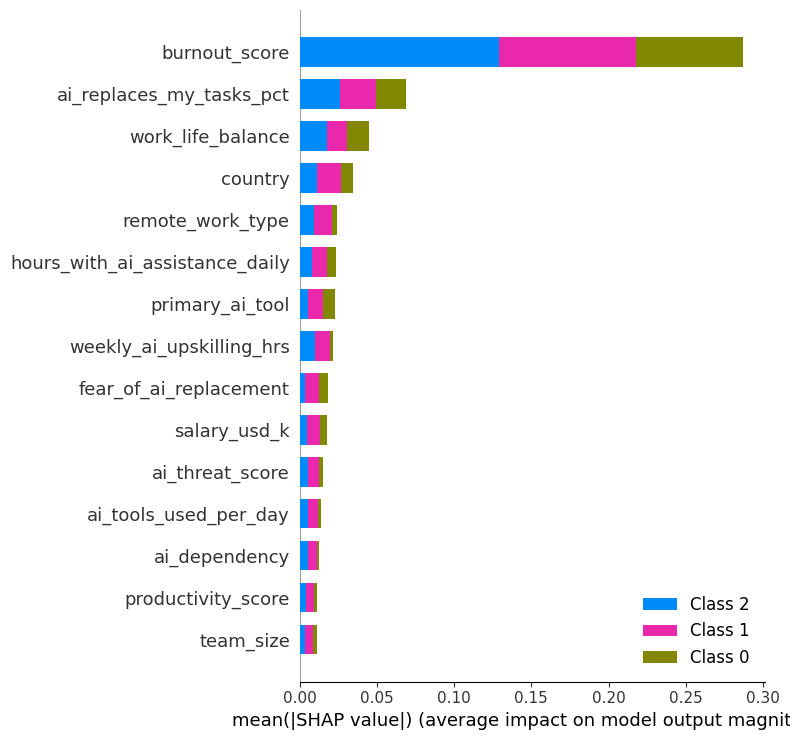

Parameter Terbaik
{'n_estimators': 706, 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2'}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.8390
2. Test Accuracy            : 0.6089
3. Test F1-Score (Macro)    : 0.5544
4. Test Precision (Macro)   : 0.5419
5. Test Recall (Macro)      : 0.5735
6. CV Accuracy Mean (k=3) : 0.5686

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3934    0.4800    0.4324        50
Medium/Neutral     0.7108    0.6321    0.6692       280
          High     0.5214    0.6083    0.5615       120

      accuracy                         0.6089       450
     macro avg     0.5419    0.5735    0.5544       450
  weighted avg     0.6251    0.6089    0.6142       450

-------------------------------------------------------
⏳ Mengekstrak data da

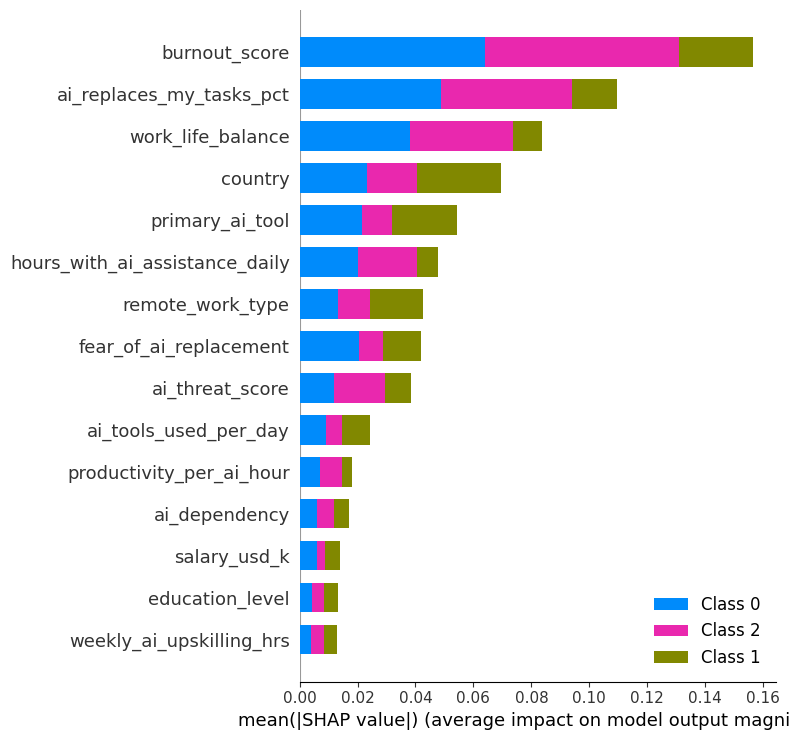

Parameter Terbaik
{'n_estimators': 217, 'max_depth': 24, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_features': None}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.7714
2. Test Accuracy            : 0.5911
3. Test F1-Score (Macro)    : 0.5494
4. Test Precision (Macro)   : 0.5324
5. Test Recall (Macro)      : 0.5899
6. CV Accuracy Mean (k=3) : 0.5524

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3600    0.5400    0.4320        50
Medium/Neutral     0.7207    0.5714    0.6375       280
          High     0.5163    0.6583    0.5788       120

      accuracy                         0.5911       450
     macro avg     0.5324    0.5899    0.5494       450
  weighted avg     0.6261    0.5911    0.5990       450

-------------------------------------------------------
⏳ Mengekstrak data dan

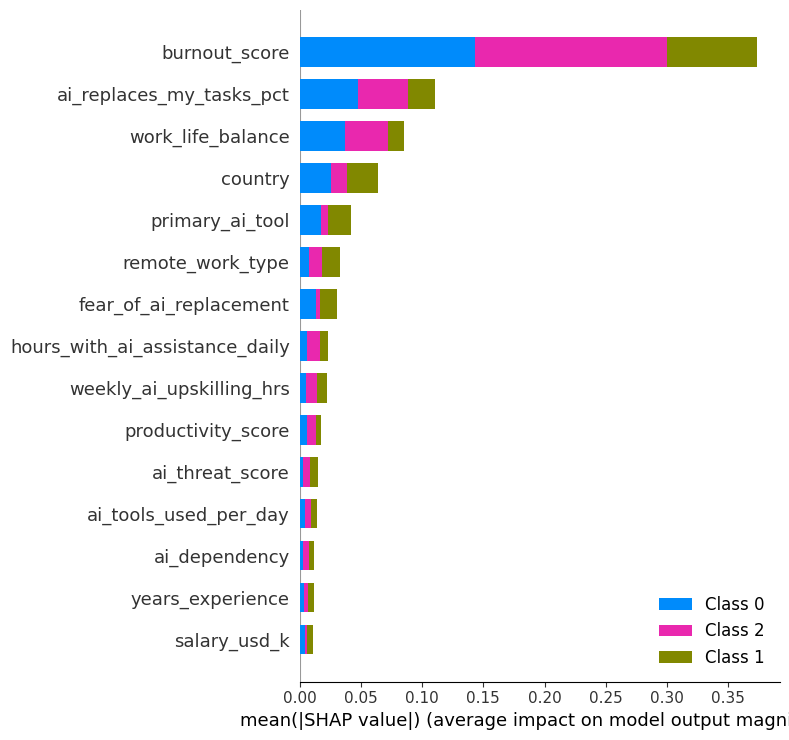

In [ ]:
algo_name = 'Extra Trees'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

Parameter Terbaik
{'n_estimators': 161, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 14, 'max_features': None}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.7305
2. Test Accuracy            : 0.6778
3. Test F1-Score (Macro)    : 0.4541
4. Test Precision (Macro)   : 0.7029
5. Test Recall (Macro)      : 0.4478
6. CV Accuracy Mean (k=3) : 0.6505

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.7500    0.0600    0.1111        50
Medium/Neutral     0.6762    0.9250    0.7813       280
          High     0.6825    0.3583    0.4699       120

      accuracy                         0.6778       450
     macro avg     0.7029    0.4478    0.4541       450
  weighted avg     0.6861    0.6778    0.6238       450

-------------------------------------------------------
⏳ Mengekstrak data dan 

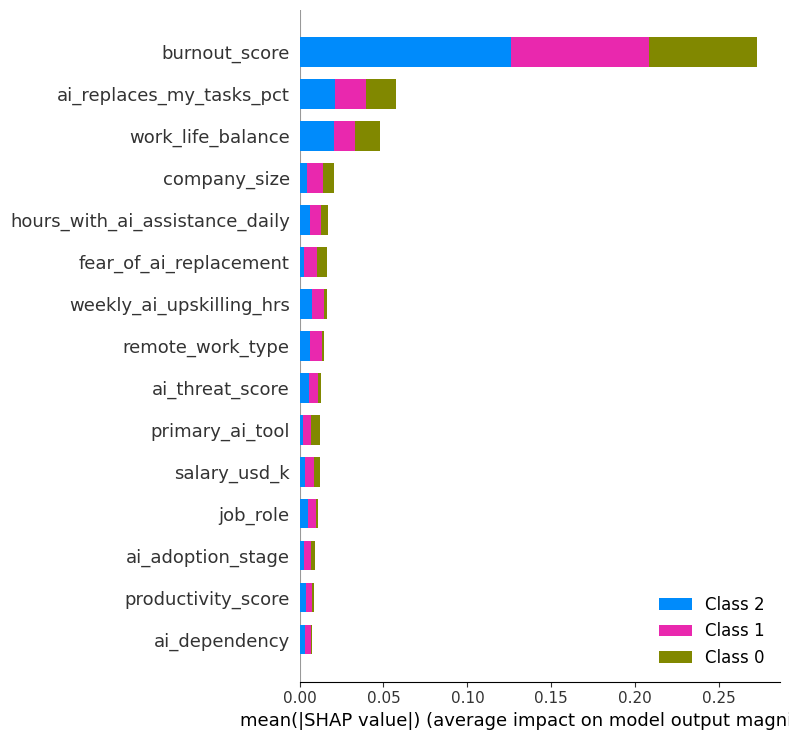

Parameter Terbaik
{'n_estimators': 738, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': None}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.5886
2. Test Accuracy            : 0.5022
3. Test F1-Score (Macro)    : 0.4939
4. Test Precision (Macro)   : 0.4898
5. Test Recall (Macro)      : 0.5995
6. CV Accuracy Mean (k=3) : 0.4962

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3130    0.7200    0.4364        50
Medium/Neutral     0.6974    0.3786    0.4907       280
          High     0.4590    0.7000    0.5545       120

      accuracy                         0.5022       450
     macro avg     0.4898    0.5995    0.4939       450
  weighted avg     0.5911    0.5022    0.5017       450

-------------------------------------------------------
⏳ Mengekstrak data dan fi

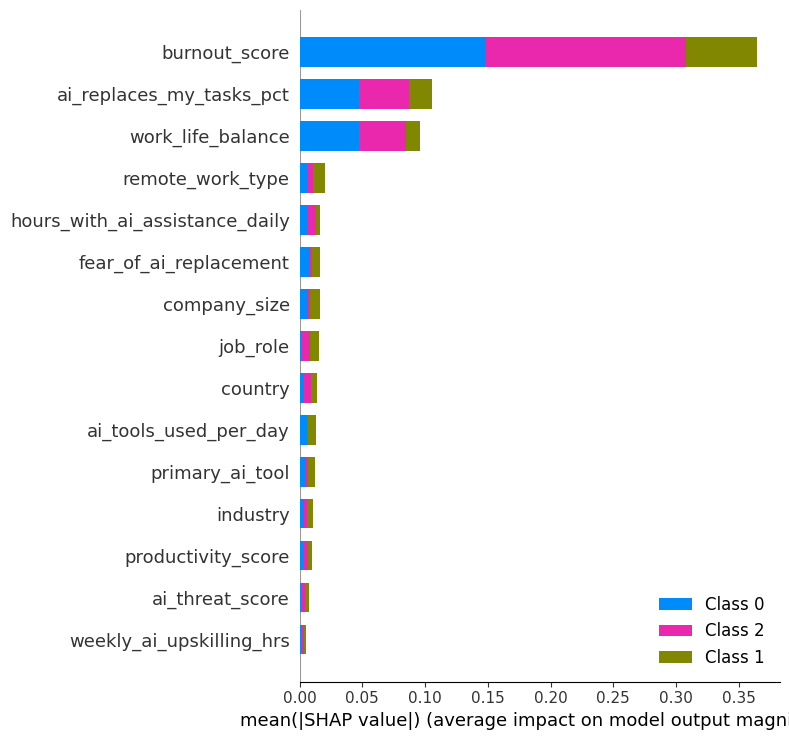

Parameter Terbaik
{'n_estimators': 592, 'max_depth': 36, 'min_samples_split': 12, 'min_samples_leaf': 16, 'max_features': None}
⏳ Sedang memproses evaluasi untuk Extra Trees...

🏆 SUMMARY METRICS : EXTRA TREES 🏆
1. Train Accuracy           : 0.7495
2. Test Accuracy            : 0.5578
3. Test F1-Score (Macro)    : 0.5270
4. Test Precision (Macro)   : 0.5109
5. Test Recall (Macro)      : 0.5814
6. CV Accuracy Mean (k=3) : 0.5438

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3452    0.5800    0.4328        50
Medium/Neutral     0.7059    0.5143    0.5950       280
          High     0.4815    0.6500    0.5532       120

      accuracy                         0.5578       450
     macro avg     0.5109    0.5814    0.5270       450
  weighted avg     0.6060    0.5578    0.5659       450

-------------------------------------------------------
⏳ Mengekstrak data dan

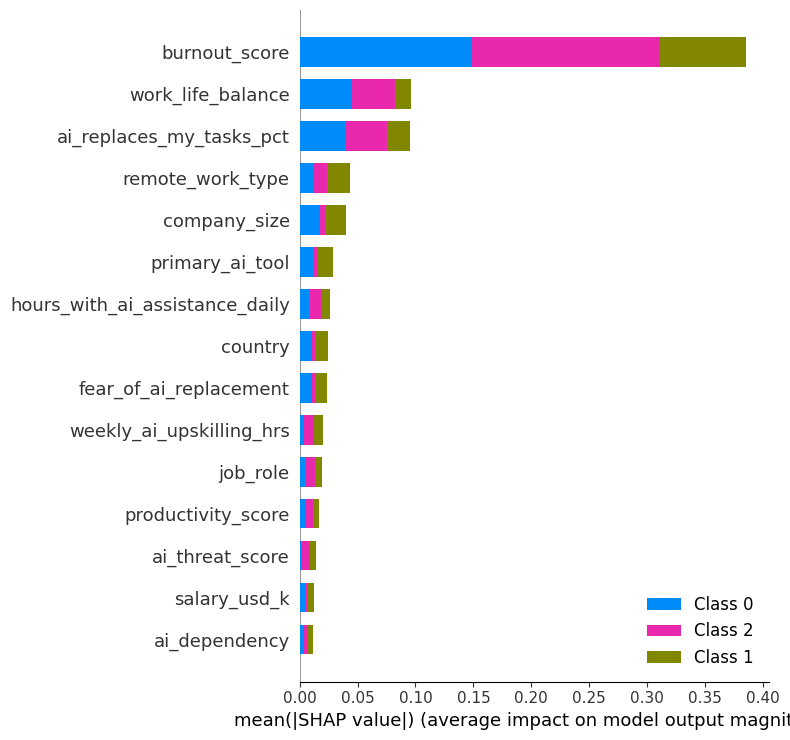

In [ ]:
algo_name = 'Extra Trees'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_base_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

## Stack

### Logistic Regression

⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.7248
2. Test Accuracy            : 0.6556
3. Test F1-Score (Macro)    : 0.4564
4. Test Precision (Macro)   : 0.6104
5. Test Recall (Macro)      : 0.4477
6. CV Accuracy Mean (k=3) : 0.6533

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.5714    0.0800    0.1404        50
Medium/Neutral     0.6722    0.8714    0.7589       280
          High     0.5875    0.3917    0.4700       120

      accuracy                         0.6556       450
     macro avg     0.6104    0.4477    0.4564       450
  weighted avg     0.6384    0.6556    0.6132       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. P

  0%|          | 0/200 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


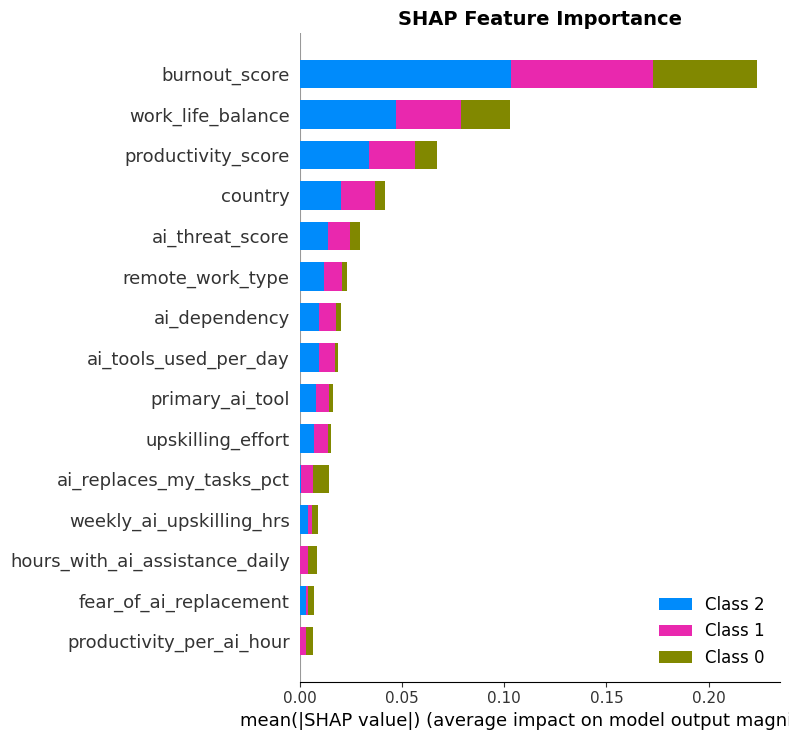

⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 1.0000
2. Test Accuracy            : 0.6467
3. Test F1-Score (Macro)    : 0.5406
4. Test Precision (Macro)   : 0.5656
5. Test Recall (Macro)      : 0.5254
6. CV Accuracy Mean (k=3) : 0.6057

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4286    0.3000    0.3529        50
Medium/Neutral     0.6981    0.7679    0.7313       280
          High     0.5701    0.5083    0.5374       120

      accuracy                         0.6467       450
     macro avg     0.5656    0.5254    0.5406       450
  weighted avg     0.6340    0.6467    0.6376       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. P

  0%|          | 0/200 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


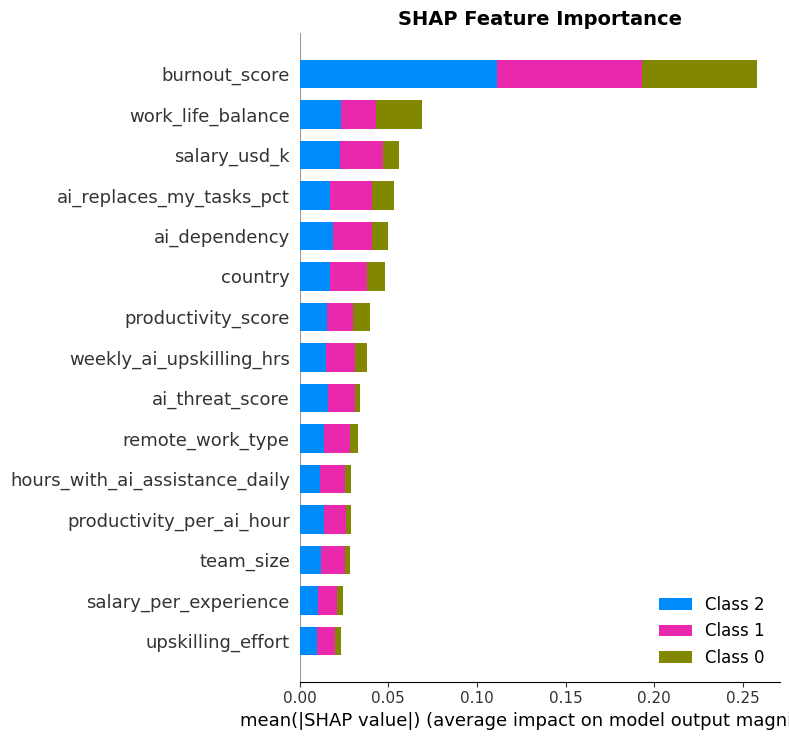

⏳ Sedang memproses evaluasi untuk Logistic Regression...

🏆 SUMMARY METRICS : LOGISTIC REGRESSION 🏆
1. Train Accuracy           : 0.6857
2. Test Accuracy            : 0.5400
3. Test F1-Score (Macro)    : 0.5168
4. Test Precision (Macro)   : 0.5040
5. Test Recall (Macro)      : 0.5869
6. CV Accuracy Mean (k=3) : 0.5229

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.3297    0.6000    0.4255        50
Medium/Neutral     0.7049    0.4607    0.5572       280
          High     0.4773    0.7000    0.5676       120

      accuracy                         0.5400       450
     macro avg     0.5040    0.5869    0.5168       450
  weighted avg     0.6025    0.5400    0.5454       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. P

  0%|          | 0/200 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


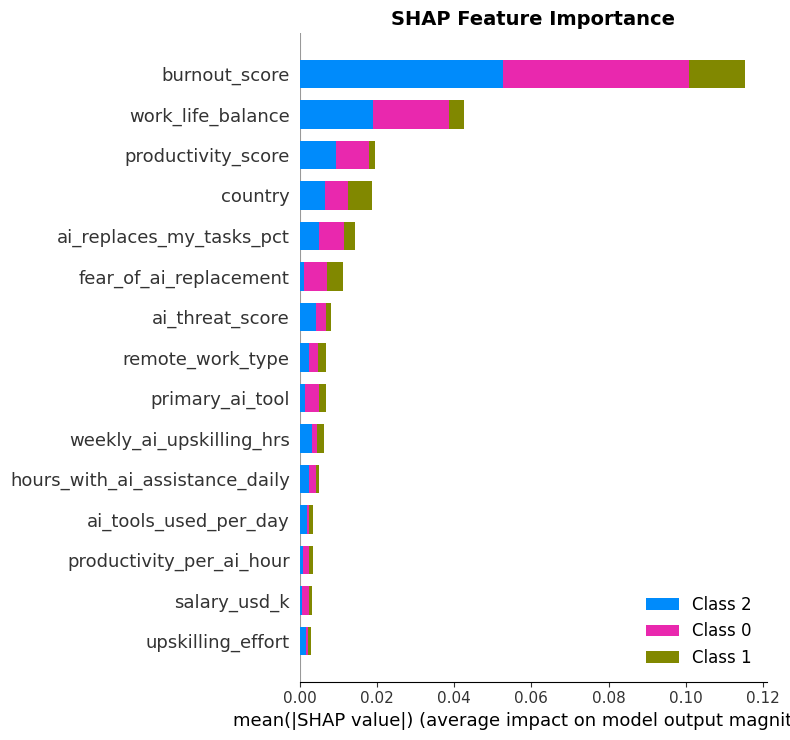

In [31]:
algo_name = 'Logistic Regression'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_stack_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

In [ ]:
algo_name = 'Logistic Regression'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_stack_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

### Ridge Classifier




⏳ Sedang memproses evaluasi untuk Ridge Classifier...

🏆 SUMMARY METRICS : RIDGE CLASSIFIER 🏆
1. Train Accuracy           : 0.7733
2. Test Accuracy            : 0.6778
3. Test F1-Score (Macro)    : 0.4816
4. Test Precision (Macro)   : 0.6741
5. Test Recall (Macro)      : 0.4626
6. CV Accuracy Mean (k=3) : 0.6314

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.6667    0.1200    0.2034        50
Medium/Neutral     0.6781    0.9179    0.7800       280
          High     0.6774    0.3500    0.4615       120

      accuracy                         0.6778       450
     macro avg     0.6741    0.4626    0.4816       450
  weighted avg     0.6766    0.6778    0.6310       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. Proses 

  0%|          | 0/100 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


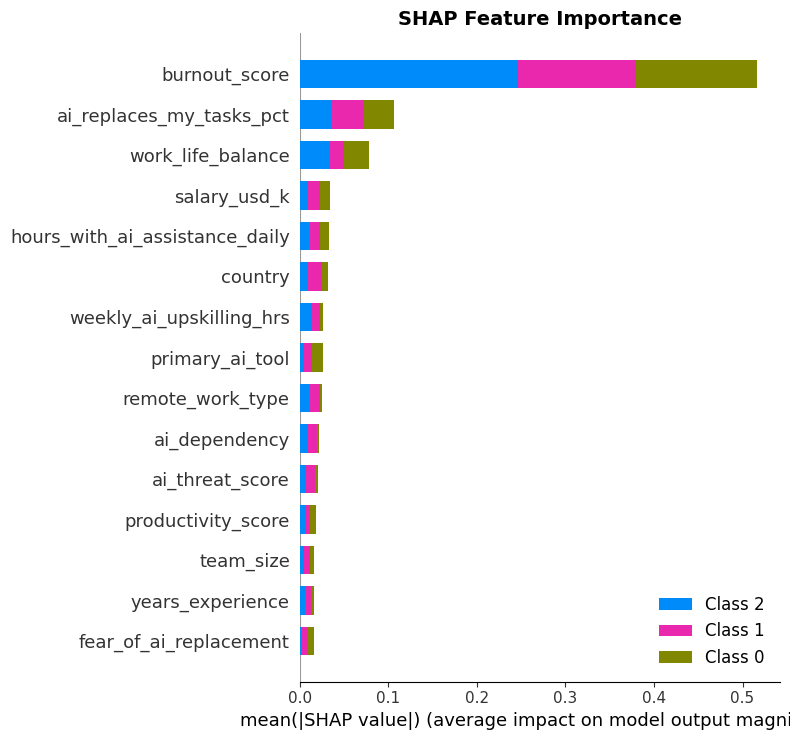

⏳ Sedang memproses evaluasi untuk Ridge Classifier...

🏆 SUMMARY METRICS : RIDGE CLASSIFIER 🏆
1. Train Accuracy           : 0.8971
2. Test Accuracy            : 0.6422
3. Test F1-Score (Macro)    : 0.5301
4. Test Precision (Macro)   : 0.5728
5. Test Recall (Macro)      : 0.5096
6. CV Accuracy Mean (k=3) : 0.6171

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4828    0.2800    0.3544        50
Medium/Neutral     0.6865    0.7821    0.7312       280
          High     0.5490    0.4667    0.5045       120

      accuracy                         0.6422       450
     macro avg     0.5728    0.5096    0.5301       450
  weighted avg     0.6272    0.6422    0.6289       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. Proses 

  0%|          | 0/100 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


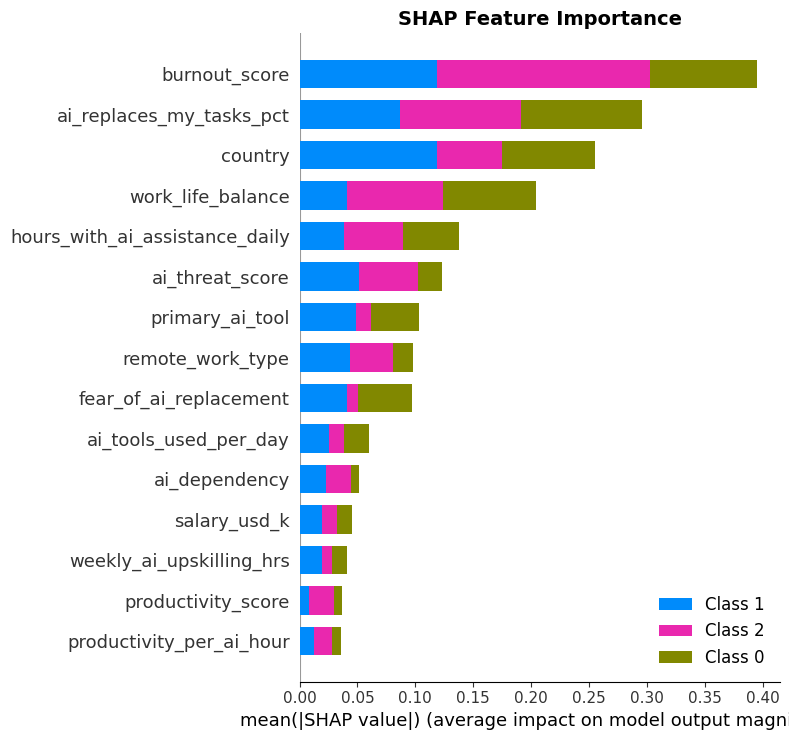

⏳ Sedang memproses evaluasi untuk Ridge Classifier...

🏆 SUMMARY METRICS : RIDGE CLASSIFIER 🏆
1. Train Accuracy           : 0.8057
2. Test Accuracy            : 0.6378
3. Test F1-Score (Macro)    : 0.5588
4. Test Precision (Macro)   : 0.5601
5. Test Recall (Macro)      : 0.5575
6. CV Accuracy Mean (k=3) : 0.5952

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4082    0.4000    0.4040        50
Medium/Neutral     0.7092    0.7143    0.7117       280
          High     0.5630    0.5583    0.5607       120

      accuracy                         0.6378       450
     macro avg     0.5601    0.5575    0.5588       450
  weighted avg     0.6368    0.6378    0.6373       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. Proses 

  0%|          | 0/100 [00:00<?, ?it/s]

🧩 Merapikan dan menggabungkan nama fitur (OHE & Scaler)...


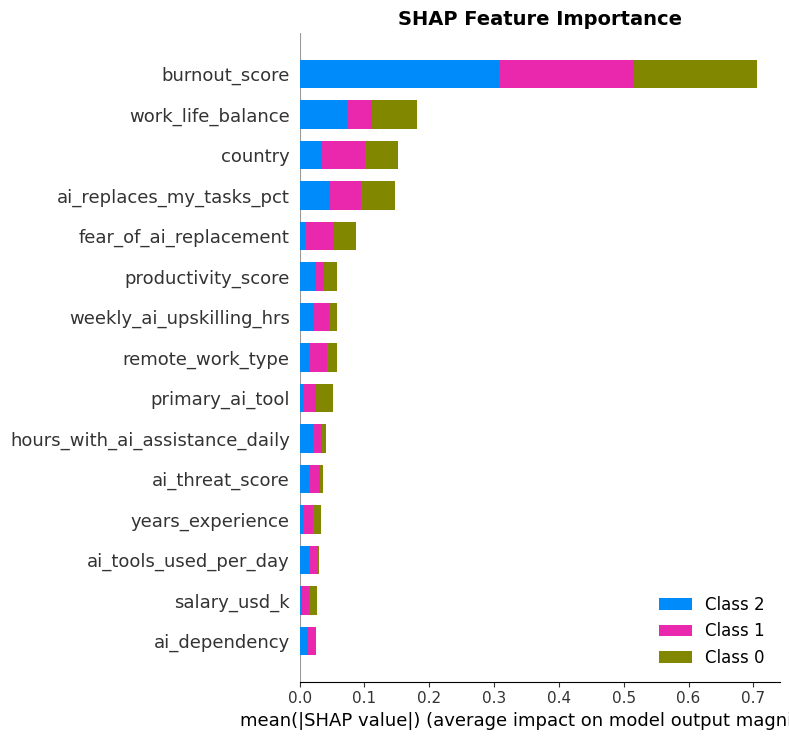

In [36]:
algo_name = 'Ridge Classifier'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_stack_algo(algo_name, i),
    wScale = wScale,
    wSmote = wSmote,
    fs='manual'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

In [37]:
algo_name = 'Ridge Classifier'

for i in range(3):

  wScale = False if i == 1 else True
  wSmote = False if i == 0 else True

  model = getPipeline(
    get_stack_algo(algo_name, i, 'rf'),
    wScale = wScale,
    wSmote = wSmote,
    fs='rf'
  )

  evaluate_final_metrics(model, model_name=algo_name, cv_folds=3)
  show_pipeline_shap(model, X_train, max_display=15, title="SHAP Feature Importance")

⏳ Sedang memproses evaluasi untuk Ridge Classifier...

🏆 SUMMARY METRICS : RIDGE CLASSIFIER 🏆
1. Train Accuracy           : 0.6629
2. Test Accuracy            : 0.6622
3. Test F1-Score (Macro)    : 0.4544
4. Test Precision (Macro)   : 0.5858
5. Test Recall (Macro)      : 0.4449
6. CV Accuracy Mean (k=3) : 0.6467

📋 CLASSIFICATION REPORT (TEST DATA) 📋
-------------------------------------------------------
                precision    recall  f1-score   support

           Low     0.4444    0.0800    0.1356        50
Medium/Neutral     0.6711    0.8964    0.7676       280
          High     0.6418    0.3583    0.4599       120

      accuracy                         0.6622       450
     macro avg     0.5858    0.4449    0.4544       450
  weighted avg     0.6381    0.6622    0.6153       450

-------------------------------------------------------
⏳ Mengekstrak data dan fitur dari pipeline untuk SHAP Feature Importance...
📊 Menghitung nilai SHAP...
⚠️ Model Stacking terdeteksi. Proses 

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 